# User Analytics in the Telecommunication 


In [266]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [267]:
df=pd.read_excel('telcom_data.xlsx', sheet_name='Sheet1',
dtype={
    'MSISDN/Number': str,
    'IMEI': str,
    'IMSI': str,
    'Last Location Name': str
})
df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,208201448079117,33664962239,35521209507511,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,208201909211140,33681854413,35794009006359,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,208200314458056,33760627129,35281510359387,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,208201402342131,33750343200,35356610164913,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,208201401415120,33699795932,35407009745539,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [268]:
shape = df.shape
print(f"entries: {shape[0]} & features: {shape[1]}")

entries: 150001 & features: 55


In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[us]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[us]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  str           
 7   MSISDN/Number                             148935 non-null  str           
 8   IMEI                                      149429 non-null  str           
 9   Last Location Name        

In [270]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Start,150000,2019-04-26 12:36:38.953740,2019-04-04 12:01:18,2019-04-25 00:26:00.750000,2019-04-26 08:51:24.500000,2019-04-27 18:18:59.750000,2019-04-29 07:28:43,NaN
Start ms,150000.0,499.1882,0.0,250.0,499.0,749.0,999.0,288.611834
End,150000,2019-04-27 17:40:08.059673,2019-04-24 22:59:58,2019-04-26 07:30:11.500000,2019-04-27 23:02:05,2019-04-29 07:15:07.500000,2019-04-30 23:59:27,NaN
End ms,150000.0,498.80088,0.0,251.0,500.0,750.0,999.0,288.097653
Dur. (ms),150000.0,104608.560347,7142.0,57440.5,86399.0,132430.25,1859336.0,81037.621479
Avg RTT DL (ms),122172.0,109.795706,0.0,32.0,45.0,70.0,96923.0,619.782739
Avg RTT UL (ms),122189.0,17.662883,0.0,2.0,5.0,15.0,7120.0,84.793524
Avg Bearer TP DL (kbps),150000.0,13300.045927,0.0,43.0,63.0,19710.75,378160.0,23971.878541
Avg Bearer TP UL (kbps),150000.0,1770.428647,0.0,47.0,63.0,1120.0,58613.0,4625.3555
TCP DL Retrans. Vol (Bytes),61855.0,20809914.270342,2.0,35651.5,568730.0,3768308.5,4294425570.0,182566527.914748


# Data Cleaning

In [271]:
# Missing values count
missing_count = df.isnull().sum()

# Missing values percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df.sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
Nb of sec with 37500B < Vol UL,130254,86.835421
Nb of sec with 6250B < Vol UL < 37500B,111843,74.561503
Nb of sec with 125000B < Vol DL,97538,65.024900
TCP UL Retrans. Vol (Bytes),96649,64.432237
Nb of sec with 31250B < Vol DL < 125000B,93586,62.390251
Nb of sec with 1250B < Vol UL < 6250B,92894,61.928920
Nb of sec with 6250B < Vol DL < 31250B,88317,58.877607
TCP DL Retrans. Vol (Bytes),88146,58.763608
HTTP UL (Bytes),81810,54.539636
HTTP DL (Bytes),81474,54.315638


In [272]:
# dropping null entries from columns
df = df.dropna(subset=['MSISDN/Number', 'IMEI', 'IMSI', 'Bearer Id'])

# handling categorical columns
df['Last Location Name'] = df['Last Location Name'].fillna('undefined')
df['Handset Manufacturer'] = df['Handset Manufacturer'].fillna('undefined')
df['Handset Type'] = df['Handset Type'].fillna('undefined')

# filling remaining numerical stuffs with 0 due to unused bandwidth
df = df.fillna(0)

# dropping columns
df = df.drop(columns=['Dur. (ms).1', 'Start', 'Start ms', 'End', 'End ms'])

In [273]:
# parsing identifiers back to int64 from str
id_cols = ['MSISDN/Number', 'IMEI', 'IMSI']
df[id_cols] = df[id_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')

duplicates = df.duplicated().sum()
if duplicates == 0:
    print('0 duplicates found')
else:
    df.drop_duplicates(inplace=True)
    print(f'{duplicates} duplicates found')

0 duplicates found


In [274]:
# Insights - 
# Data Overview and Cleaning
# In this section we will load the dataset, clean the column names, detect missing values, convert date columns to datetime, and fill numeric missing values using column means and categorical missing values using modes.

# We will also identify outliers and clean them so that downstream analysis is reliable.

In [275]:
# # Convert column names to a standard Python-friendly format for easier use in code
# # This replaces spaces, special characters, and symbols

# df.columns = [c.strip().replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('<', 'lt_').replace('>', 'gt_').replace('%', 'pct').replace('.', '').replace('-', '_') for c in df.columns] 

# # Convert date columns to datetime so time-based analysis works correctly
# for col in ['Start', 'End']:
#     if col in df.columns:
#         df[col] = pd.to_datetime(df[col], errors='coerce')

# # Identify numeric columns and report missing values
# numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# missing_summary = df.isna().sum().sort_values(ascending=False).head(30)
# print('Numeric columns count:', len(numeric_cols))
# print('Missing values summary:')
# print(missing_summary)

# # Fill numeric missing values with the column mean
# for col in numeric_cols:
#     mean_value = df[col].mean()
#     df[col] = df[col].fillna(mean_value)

# # Fill categorical missing values with the column mode
# for col in df.select_dtypes(include=['object']).columns:
#     if df[col].isna().any():
#         df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown')

# # Replace extreme outliers beyond 3 standard deviations with the column mean
# for col in numeric_cols:
#     mean_val, std_val = df[col].mean(), df[col].std()
#     if pd.notna(std_val) and std_val > 0:
#         outlier_mask = (df[col] > mean_val + 3 * std_val) | (df[col] < mean_val - 3 * std_val)
#         df.loc[outlier_mask, col] = mean_val

# print(df.isna().sum().sort_values(ascending=False).head(20))
# print('Cleaning complete. Missing values after clean:')

In [276]:
print(df.columns)


Index(['Bearer Id', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Last Location Name', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
       'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Handset Manufacturer', 'Handset Type',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec wi

In [277]:
df.columns

Index(['Bearer Id', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Last Location Name', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
       'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Handset Manufacturer', 'Handset Type',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec wi

# Task1. USER OVERVIEW ANALYSIS

In [278]:
# Insights
# In this section, we identify the most popular handsets and handset manufacturers.

# Then we aggregate user-level session metrics to understand how many sessions, total duration, and traffic each user generated.

Handset Type
Huawei B528S-23A                19727
Apple iPhone 6S (A1688)          9413
Apple iPhone 6 (A1586)           9012
undefined                        8931
Apple iPhone 7 (A1778)           6304
Apple iPhone Se (A1723)          5176
Apple iPhone 8 (A1905)           4985
Apple iPhone Xr (A2105)          4562
Samsung Galaxy S8 (Sm-G950F)     4480
Apple iPhone X (A1901)           3810
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\2438716354.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


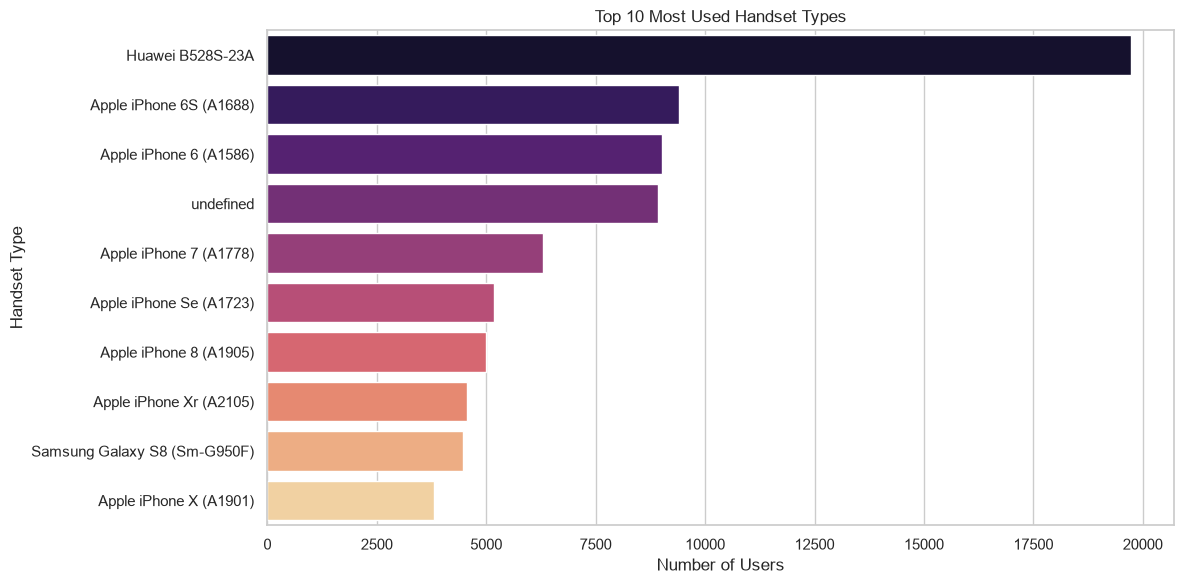

In [279]:
# Top 10 Handset Types
top10_types = df["Handset Type"].value_counts().head(10)

print(top10_types)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    x=top10_types.values,
    y=top10_types.index,
    palette="magma"
)

plt.title("Top 10 Most Used Handset Types")
plt.xlabel("Number of Users")
plt.ylabel("Handset Type")
plt.tight_layout()
plt.show()


Handset Manufacturer
Apple      59464
Samsung    40579
Huawei     34366
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\3842402317.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


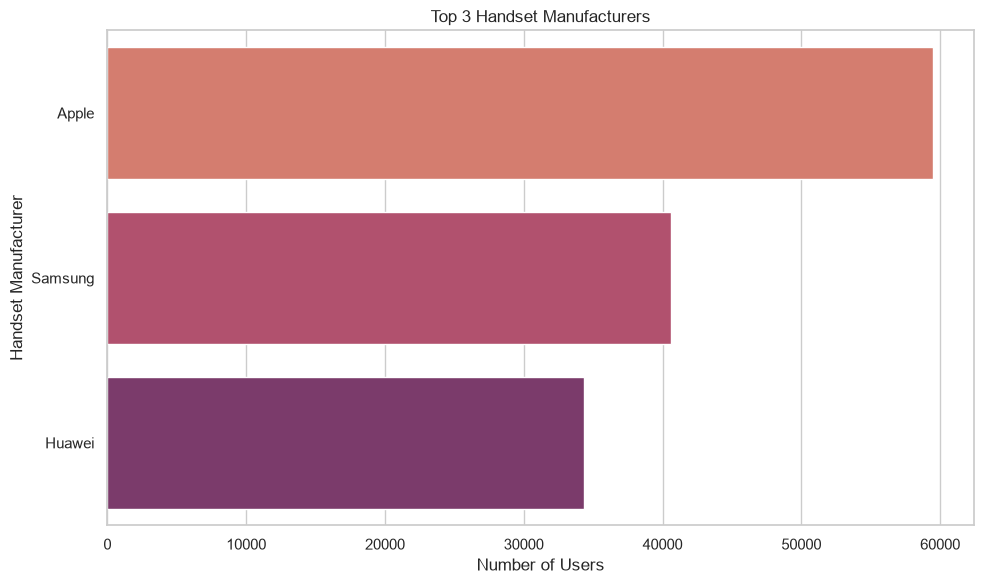

In [280]:
# Top 3 Handset Manufacturers
top_manufacturer = df["Handset Manufacturer"].value_counts().head(3)

print(top_manufacturer)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_manufacturer.values,
    y=top_manufacturer.index,
    palette="flare"
)

plt.title("Top 3 Handset Manufacturers")
plt.xlabel("Number of Users")
plt.ylabel("Handset Manufacturer")
plt.tight_layout()
plt.show()


Handset Manufacturer
Apple      59464
Samsung    40579
Huawei     34366
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\71401248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


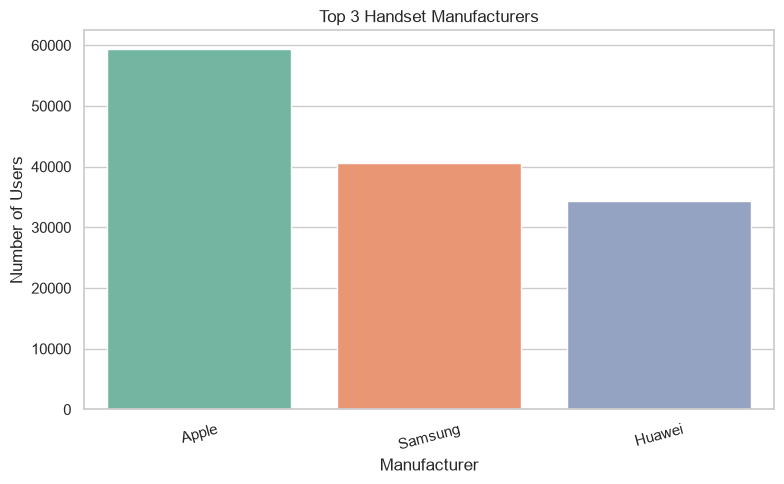

In [281]:
# Top 3 Handset Manufacturers
top3 = df["Handset Manufacturer"].value_counts().head(3)

print(top3)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    x=top3.index,
    y=top3.values,
    palette="Set2"
)

plt.title("Top 3 Handset Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Users")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Top 3 Manufacturers:
['Apple', 'Samsung', 'Huawei']
Top 5 Handsets of Apple
Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Apple iPhone 8 (A1905)     4985
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\1857691691.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


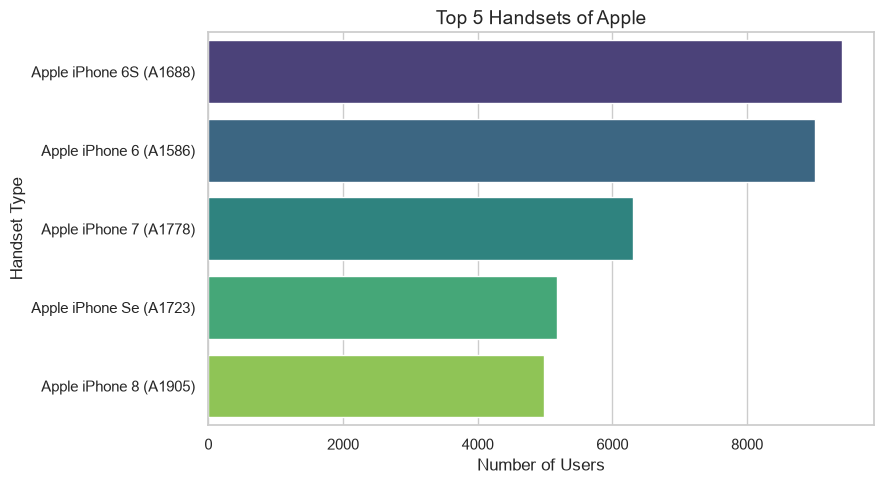

Top 5 Handsets of Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\1857691691.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


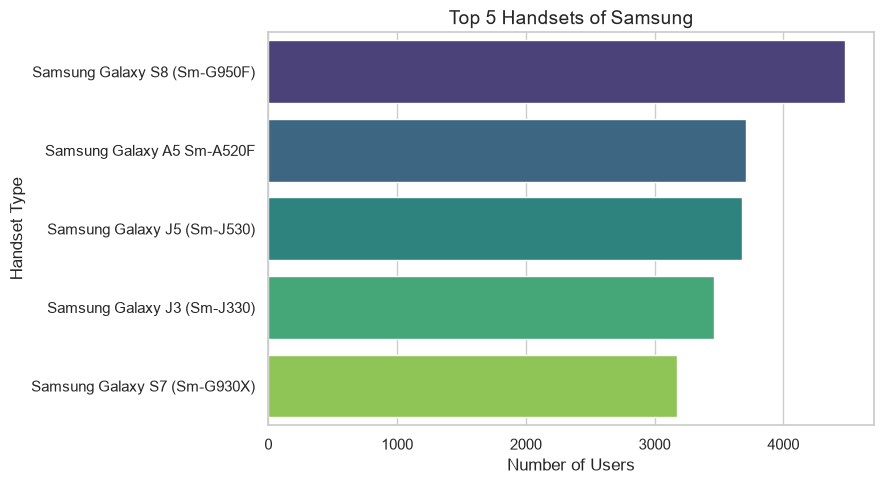

Top 5 Handsets of Huawei
Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\1857691691.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


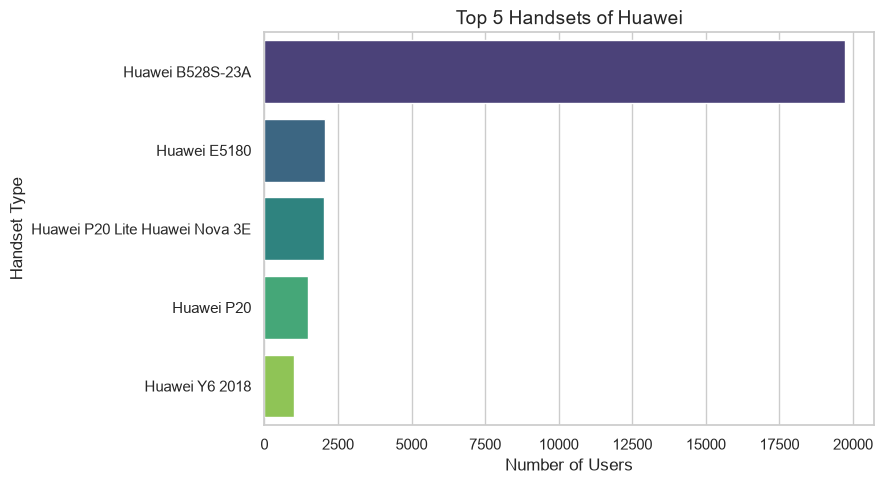

In [282]:
# Top 3 Handset Manufacturers
top3 = df["Handset Manufacturer"].value_counts().head(3).index.tolist()

print("Top 3 Manufacturers:")
print(top3)

# Top 5 Handsets of each Manufacturer
for company in top3:
    print("="*60)
    print(f"Top 5 Handsets of {company}")

    top5 = (
        df[df["Handset Manufacturer"] == company]
        ["Handset Type"]
        .value_counts()
        .head(5)
    )

    print(top5)

    # Graph
    plt.figure(figsize=(9,5))
    sns.barplot(
        x=top5.values,
        y=top5.index,
        palette="viridis"
    )
    plt.title(f"Top 5 Handsets of {company}", fontsize=14)
    plt.xlabel("Number of Users")
    plt.ylabel("Handset Type")
    plt.tight_layout()
    plt.show()


In [283]:
def check_skewness(col):
    val = col.skew()
    
    if -0.5 <= val <= 0.5:
        return "Symmetrical (Normal-ish)"
    elif 0.5 < val <= 1:
        return "Moderately Positive Skewed"
    elif val > 1:
        return "Highly Positive Skewed"
    elif -1 <= val < -0.5:
        return "Moderately Negative Skewed"
    else:
        return "Highly Negative Skewed"

def check_kurtosis(col):
    val = col.kurt()
    
    if val > 0.5:
        return "Leptokurtic (Heavy Tails / Peaked)"
    elif val < -0.5:
        return "Platykurtic (Light Tails / Flat)"
    else:
        return "Mesokurtic (Normal-like)"

# Aggregation 

Total traffic per application (Bytes):
Social Media Total    2.722655e+11
Google Total          1.162853e+12
Email Total           3.364677e+11
Youtube Total         3.372204e+12
Netflix Total         3.370060e+12
Gaming Total          6.408892e+13
Other Total           6.395425e+13
dtype: float64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\3242926641.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_per_app.index, y=total_per_app.values, palette="viridis")


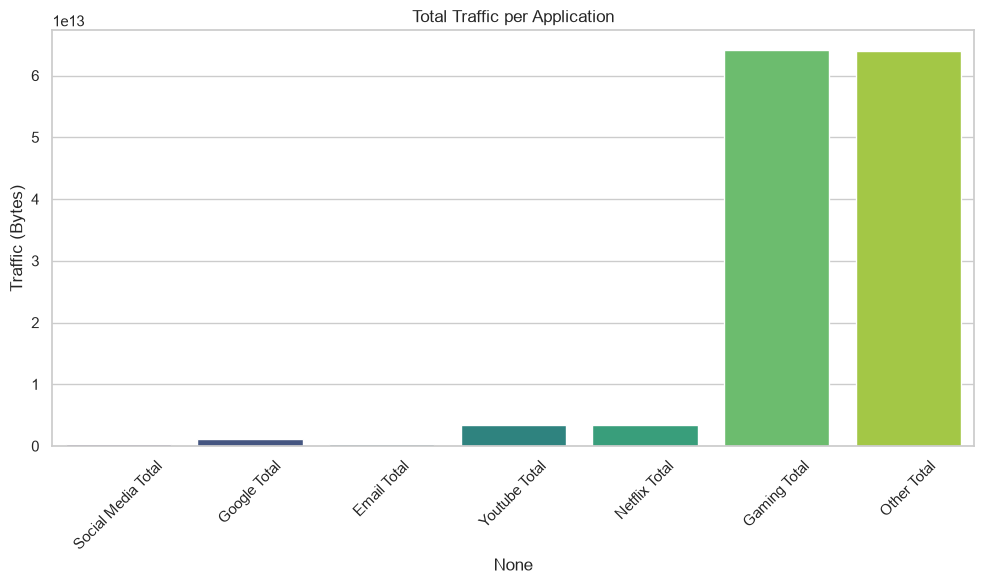

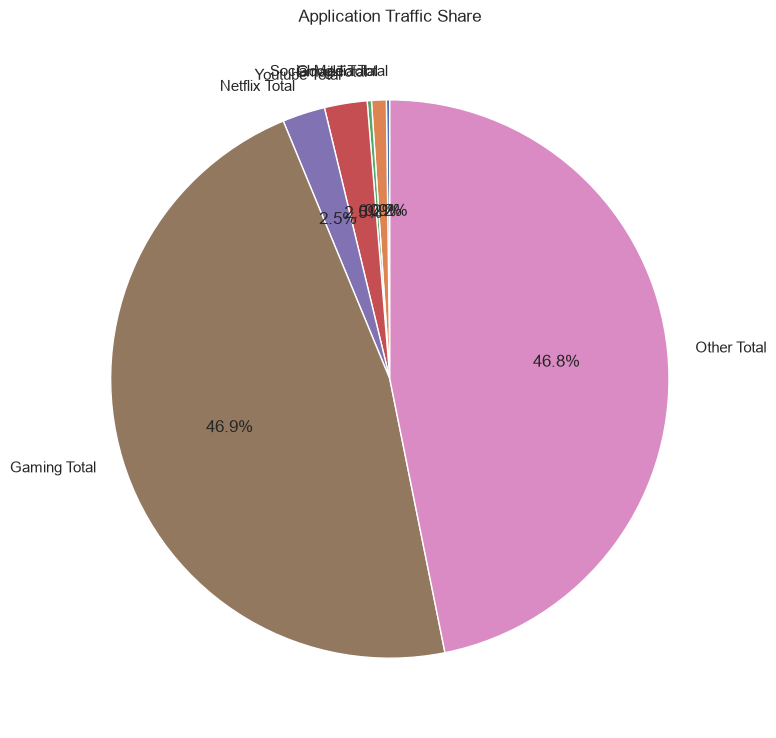

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total traffic for each application
df["Social Media Total"] = df["Social Media DL (Bytes)"] + df["Social Media UL (Bytes)"]
df["Google Total"]       = df["Google DL (Bytes)"] + df["Google UL (Bytes)"]
df["Email Total"]        = df["Email DL (Bytes)"] + df["Email UL (Bytes)"]
df["Youtube Total"]      = df["Youtube DL (Bytes)"] + df["Youtube UL (Bytes)"]
df["Netflix Total"]      = df["Netflix DL (Bytes)"] + df["Netflix UL (Bytes)"]
df["Gaming Total"]       = df["Gaming DL (Bytes)"] + df["Gaming UL (Bytes)"]
df["Other Total"]        = df["Other DL (Bytes)"] + df["Other UL (Bytes)"]

# Aggregate totals across all users
total_per_app = df[[
    "Social Media Total", "Google Total", "Email Total",
    "Youtube Total", "Netflix Total", "Gaming Total", "Other Total"
]].sum()

print("Total traffic per application (Bytes):")
print(total_per_app)

#  Plots

# Bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=total_per_app.index, y=total_per_app.values, palette="viridis")
plt.title("Total Traffic per Application")
plt.ylabel("Traffic (Bytes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(total_per_app.values, labels=total_per_app.index, autopct='%1.1f%%', startangle=90)
plt.title("Application Traffic Share")
plt.tight_layout()
plt.show()


In [285]:
df_overview = df.groupby("MSISDN/Number").agg(
    Session_Frequency=("Bearer Id", "count"),
    Total_Duration_ms=("Dur. (ms)", "sum"),
    Total_DL_Bytes=("Total DL (Bytes)", "sum"),
    Total_UL_Bytes=("Total UL (Bytes)", "sum"),

    Social_Media=("Social Media Total", "sum"),
    Google=("Google Total", "sum"),
    Email=("Email Total", "sum"),
    Youtube=("Youtube Total", "sum"),
    Netflix=("Netflix Total", "sum"),
    Gaming=("Gaming Total", "sum"),
    Other=("Other Total", "sum")
).reset_index()

df_overview["Total_Traffic"] = (
    df_overview["Total_DL_Bytes"] +
    df_overview["Total_UL_Bytes"]
)

In [286]:
df_overview.head()

,MSISDN/Number,Session_Frequency,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other,Total_Traffic
0,33601001722,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,8.786906e+08
1,33601001754,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,1.568596e+08
2,33601002511,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,5.959665e+08
3,33601007832,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,4.223207e+08
4,33601008617,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,1.457411e+09


In [287]:
num_col = df_overview.select_dtypes(include='number')
summary = num_col.describe().T

summary['median'] = num_col.median()
summary['iqr'] = summary['75%'] - summary['25%']
summary['skewness'] = df_overview.skew(numeric_only=True)
summary['kurtosis'] = df_overview.kurt(numeric_only=True)

columns_order = ['mean', 'median', 'std', 'min', '25%', 'iqr', '75%', 'max', 'skewness', 'kurtosis']
summary = summary[columns_order]
summary

,mean,median,std,min,25%,iqr,75%,max,skewness,kurtosis
MSISDN/Number,45114738050.511436,33663649735.0,2889423433406.800293,33601001722.0,33650876081.25,32560660.5,33683436741.75,882397108489451.0,281.34708,83114.379026
Session_Frequency,1.393792,1.0,0.806022,1.0,1.0,1.0,2.0,18.0,3.353461,20.742598
Total_Duration_ms,146167.156323,102740.0,186358.669675,7142.0,71308.0,101491.0,172799.0,18553754.0,20.539551,1237.832575
Total_DL_Bytes,633652680.893155,570367723.0,464555056.461013,8827082.0,314827063.75,492537426.5,807364490.25,8156743493.0,2.149144,10.679149
Total_UL_Bytes,57309422.414595,46793865.5,35657649.748135,2866892.0,36395474.75,29336518.25,65731993.0,729577380.0,2.895198,16.599142
Social_Media,2547966.816014,2303756.0,1908038.042156,1563.0,1211281.5,2096227.5,3307509.0,43374779.0,2.090459,11.519748
Google,10882434.41847,9586153.0,7544861.436829,40330.0,5942636.0,7272103.75,13214739.75,152191852.0,2.401221,12.622354
Email,3148795.810839,2799824.5,2222400.09958,18176.0,1674481.0,2172716.5,3847197.5,42418782.0,2.374521,12.599693
Youtube,31558399.279095,26800376.0,21294917.681802,78903.0,18631088.5,19296887.25,37927975.75,452958769.0,2.539667,13.967312
Netflix,31538332.309257,26718889.5,21289556.969838,184569.0,18555972.75,19420984.25,37976957.0,399519079.0,2.478571,12.692312


In [288]:
print(df.columns.tolist())


['Bearer Id', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Handset Manufacturer', 'Handset Type', 'Nb of sec with 125000B < Vol DL', 'Nb of sec with 1250B < Vol UL < 6250B', 'Nb of sec with 31250B < Vol DL < 125000B', 'Nb of sec with 37500B < Vol UL', 'Nb of sec with 6250B < Vol DL < 31250B', 'Nb of sec with 6250B < Vol UL < 37500B', 'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B', 'Social Media DL (Bytes)', 'Social Media UL (Bytes)', 'Google DL (Bytes)', 'Google UL (Bytes)', 'E

In [289]:
df_overview = df.groupby("MSISDN/Number").agg(
    Session_Frequency=("Bearer Id", "count"),
    Total_Duration_ms=("Dur. (ms)", "sum"),
    Total_DL_Bytes=("Total DL (Bytes)", "sum"),
    Total_UL_Bytes=("Total UL (Bytes)", "sum"),

    Social_Media=("Social Media Total", "sum"),
    Google=("Google Total", "sum"),
    Email=("Email Total", "sum"),
    Youtube=("Youtube Total", "sum"),
    Netflix=("Netflix Total", "sum"),
    Gaming=("Gaming Total", "sum"),
    Other=("Other Total", "sum")
).reset_index()

df_overview["Total_Traffic"] = (
    df_overview["Total_DL_Bytes"] +
    df_overview["Total_UL_Bytes"]
)

In [290]:
df_overview.head()

,MSISDN/Number,Session_Frequency,Total_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Social_Media,Google,Email,Youtube,Netflix,Gaming,Other,Total_Traffic
0,33601001722,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,8.786906e+08
1,33601001754,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,1.568596e+08
2,33601002511,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,5.959665e+08
3,33601007832,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,4.223207e+08
4,33601008617,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,1.457411e+09


In [291]:
num_col = df_overview.select_dtypes(include='number')
summary = num_col.describe().T

summary['median'] = num_col.median()
summary['iqr'] = summary['75%'] - summary['25%']
summary['skewness'] = df_overview.skew(numeric_only=True)
summary['kurtosis'] = df_overview.kurt(numeric_only=True)

columns_order = ['mean', 'median', 'std', 'min', '25%', 'iqr', '75%', 'max', 'skewness', 'kurtosis']
summary = summary[columns_order]
summary

,mean,median,std,min,25%,iqr,75%,max,skewness,kurtosis
MSISDN/Number,45114738050.511436,33663649735.0,2889423433406.800293,33601001722.0,33650876081.25,32560660.5,33683436741.75,882397108489451.0,281.34708,83114.379026
Session_Frequency,1.393792,1.0,0.806022,1.0,1.0,1.0,2.0,18.0,3.353461,20.742598
Total_Duration_ms,146167.156323,102740.0,186358.669675,7142.0,71308.0,101491.0,172799.0,18553754.0,20.539551,1237.832575
Total_DL_Bytes,633652680.893155,570367723.0,464555056.461013,8827082.0,314827063.75,492537426.5,807364490.25,8156743493.0,2.149144,10.679149
Total_UL_Bytes,57309422.414595,46793865.5,35657649.748135,2866892.0,36395474.75,29336518.25,65731993.0,729577380.0,2.895198,16.599142
Social_Media,2547966.816014,2303756.0,1908038.042156,1563.0,1211281.5,2096227.5,3307509.0,43374779.0,2.090459,11.519748
Google,10882434.41847,9586153.0,7544861.436829,40330.0,5942636.0,7272103.75,13214739.75,152191852.0,2.401221,12.622354
Email,3148795.810839,2799824.5,2222400.09958,18176.0,1674481.0,2172716.5,3847197.5,42418782.0,2.374521,12.599693
Youtube,31558399.279095,26800376.0,21294917.681802,78903.0,18631088.5,19296887.25,37927975.75,452958769.0,2.539667,13.967312
Netflix,31538332.309257,26718889.5,21289556.969838,184569.0,18555972.75,19420984.25,37976957.0,399519079.0,2.478571,12.692312


# Univarite

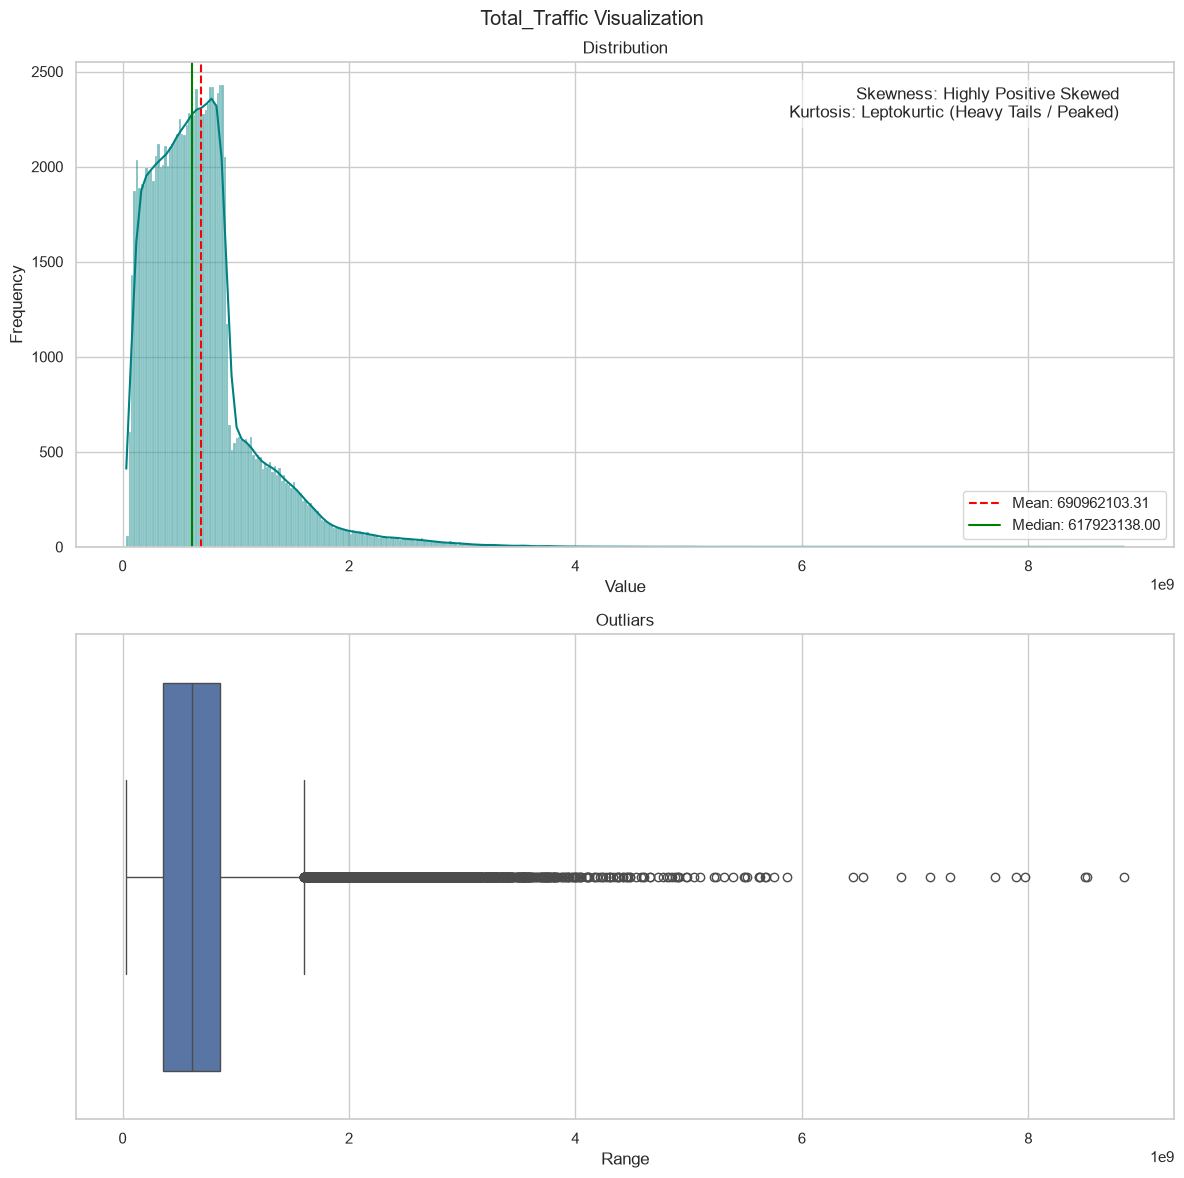

In [292]:
# Total_Traffic
fig = plt.figure(figsize=(12, 12))
sns.set_theme(style="whitegrid")

curr_col = 'Total_Traffic'

# mean median vals
mean_val = df_overview[curr_col].mean()
median_val = df_overview[curr_col].median()

# Histogram
plt.subplot(2, 1, 1)
ax1 = sns.histplot(data=df_overview, x=curr_col, color='teal', kde=True)

# Mean & Median lines
ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax1.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

# Skewness and kurtosis labels
stats_text = f'Skewness: {check_skewness(df_overview[curr_col])}\nKurtosis: {check_kurtosis(df_overview[curr_col])}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, verticalalignment='top', 
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax1.legend()

ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(2, 1, 2)
ax2 = sns.boxplot(data=df_overview, x=curr_col)
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Total_Traffic Visualization")
plt.tight_layout()
plt.show()

In [293]:
 #*Interpretation* - Total traffic exhibits a right-skewed distribution, indicating that while most customers consume moderate amounts of data, a few heavy users account for exceptionally high traffic volumes.

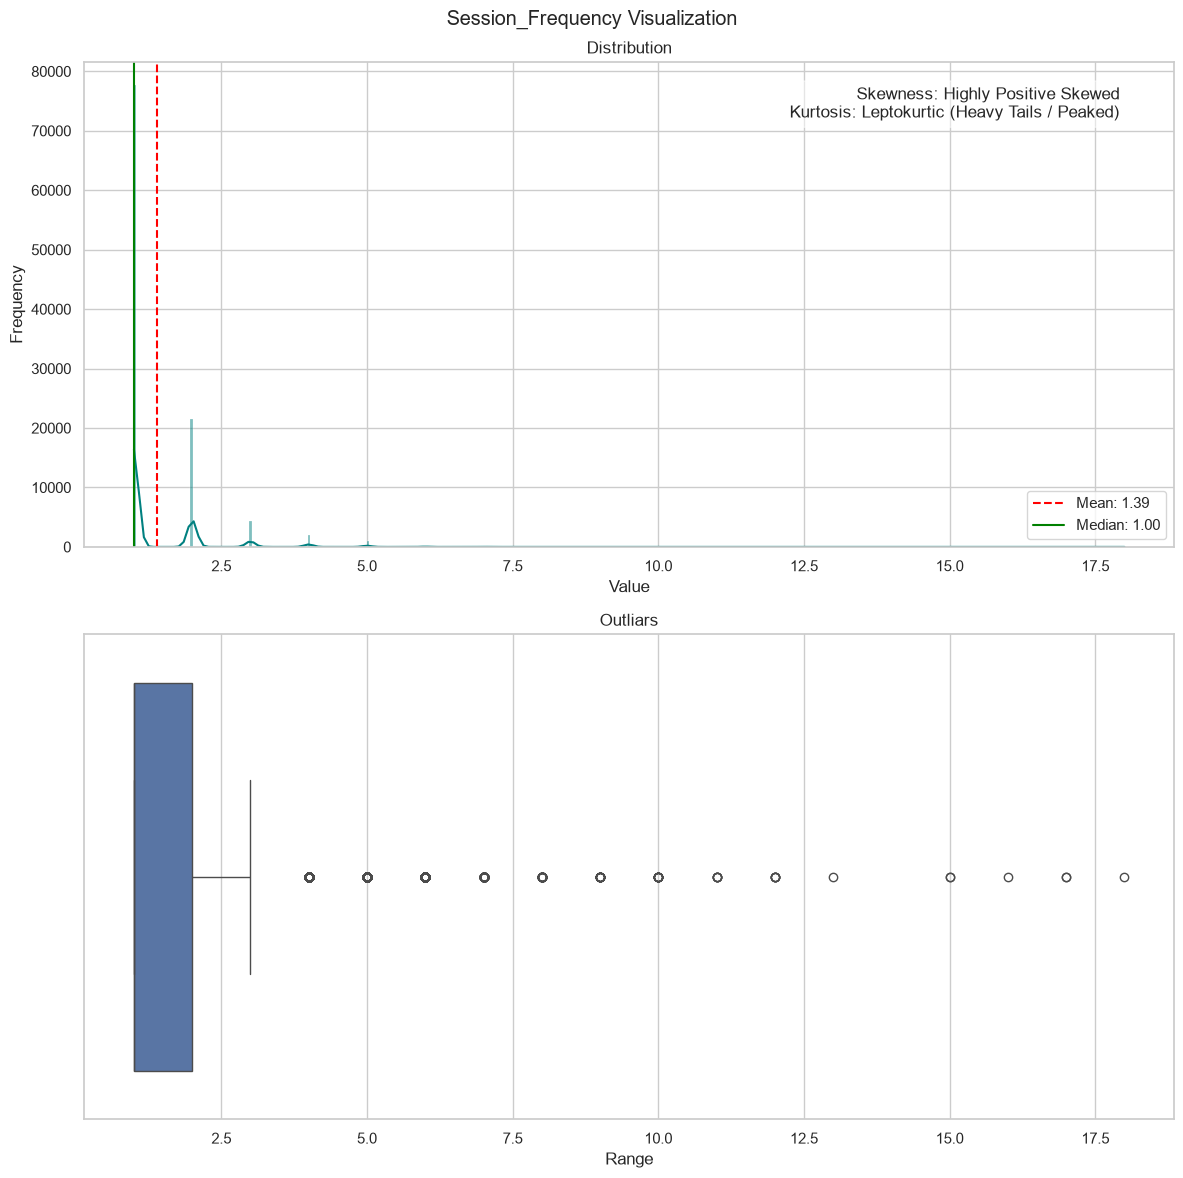

In [294]:
# Session_Frequency
fig = plt.figure(figsize=(12, 12))
sns.set_theme(style="whitegrid")

curr_col = 'Session_Frequency'

# mean median vals
mean_val = df_overview[curr_col].mean()
median_val = df_overview[curr_col].median()

# Histogram
plt.subplot(2, 1, 1)
ax1 = sns.histplot(data=df_overview, x=curr_col, color='teal', kde=True)

# Mean & Median lines
ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax1.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

# Skewness and kurtosis labels
stats_text = f'Skewness: {check_skewness(df_overview[curr_col])}\nKurtosis: {check_kurtosis(df_overview[curr_col])}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, verticalalignment='top', 
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax1.legend()

ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(2, 1, 2)
ax2 = sns.boxplot(data=df_overview, x=curr_col)
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Session_Frequency Visualization")
plt.tight_layout()
plt.show()

In [295]:
> #### **Interpretation**: The distribution is highly positively skewed, indicating that most users have low session frequency while a few users generate many sessions.

SyntaxError: invalid syntax (64029246.py, line 1)

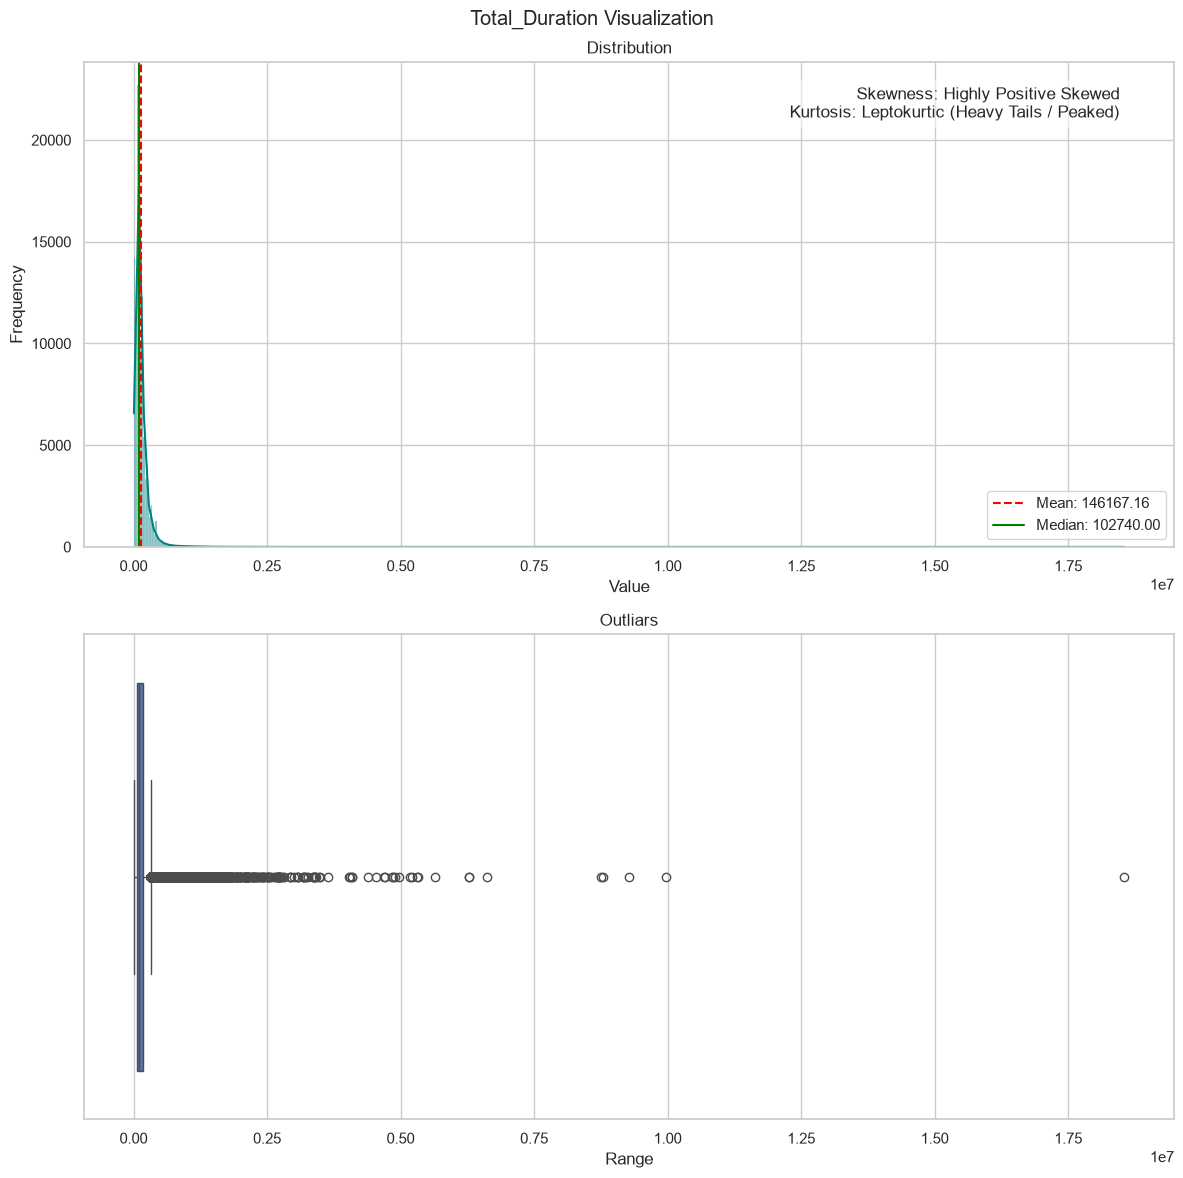

In [ ]:
# Total_Duration_ms
fig = plt.figure(figsize=(12, 12))
sns.set_theme(style="whitegrid")

curr_col = 'Total_Duration_ms'

# mean median vals
mean_val = df_overview[curr_col].mean()
median_val = df_overview[curr_col].median()

# Histogram
plt.subplot(2, 1, 1)
ax1 = sns.histplot(data=df_overview, x=curr_col, color='teal', kde=True)

# Mean & Median lines
ax1.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax1.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

# Skewness and kurtosis labels
stats_text = f'Skewness: {check_skewness(df_overview[curr_col])}\nKurtosis: {check_kurtosis(df_overview[curr_col])}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, verticalalignment='top', 
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax1.legend()

ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(2, 1, 2)
ax2 = sns.boxplot(data=df_overview, x=curr_col)
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Total_Duration Visualization")
plt.tight_layout()
plt.show()

In [ ]:
# > #### **Interpretation**: The distribution is highly positively skewed with several extreme values, suggesting that a small number of customers remain connected for significantly longer durations.

 # Bivariate Analysis

In [ ]:
# - ### Bivariate Analysis

# The relationship between application-specific data usage and the overall data consumption of customers and identify usage patterns.

In [ ]:
app_cols = [
    "Social_Media",
    "Google",
    "Email",
    "Youtube",
    "Netflix",
    "Gaming",
    "Other"
]

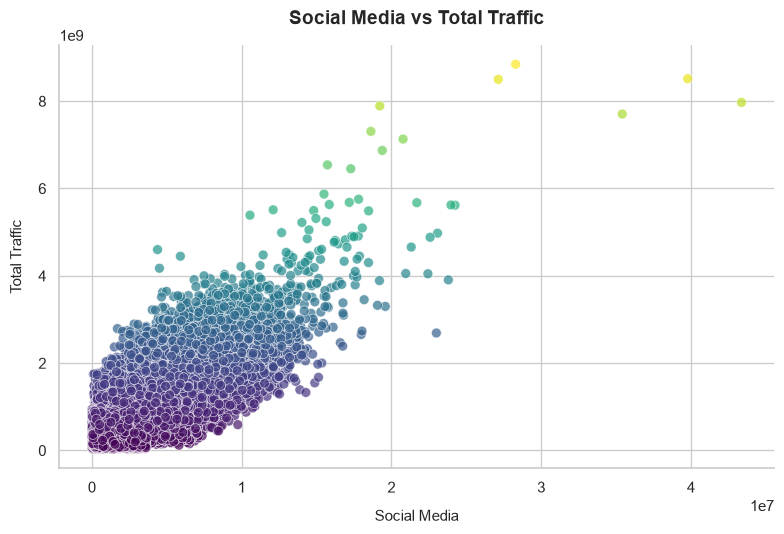

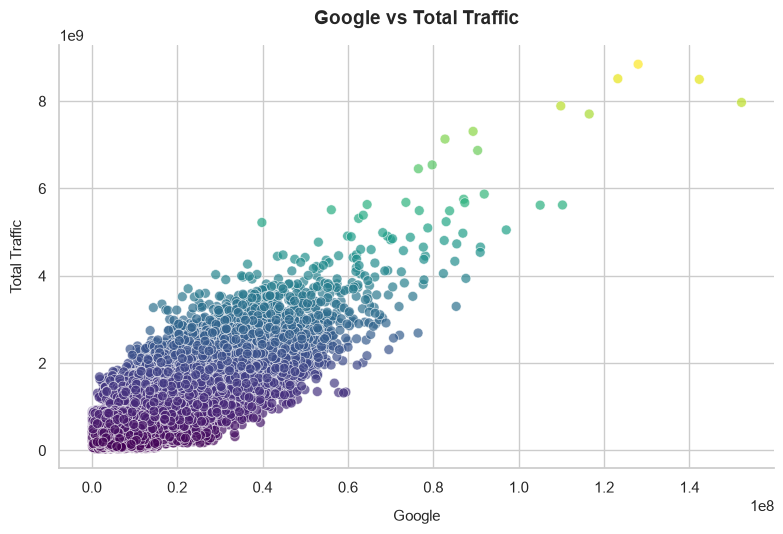

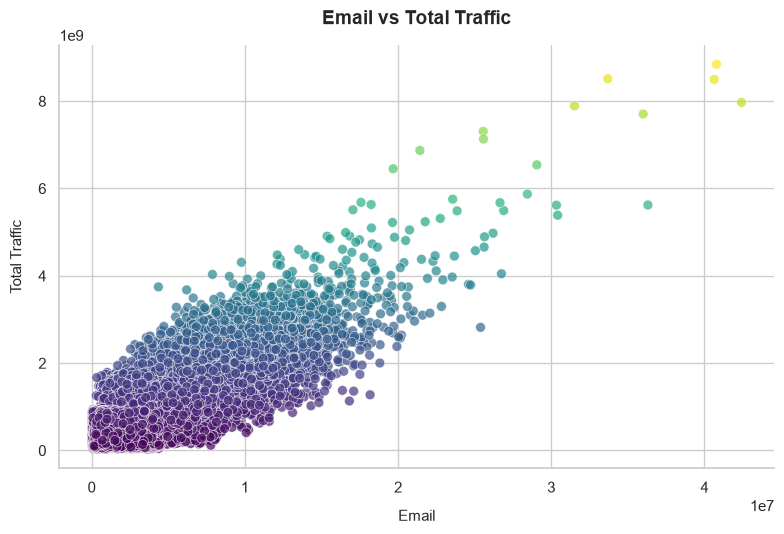

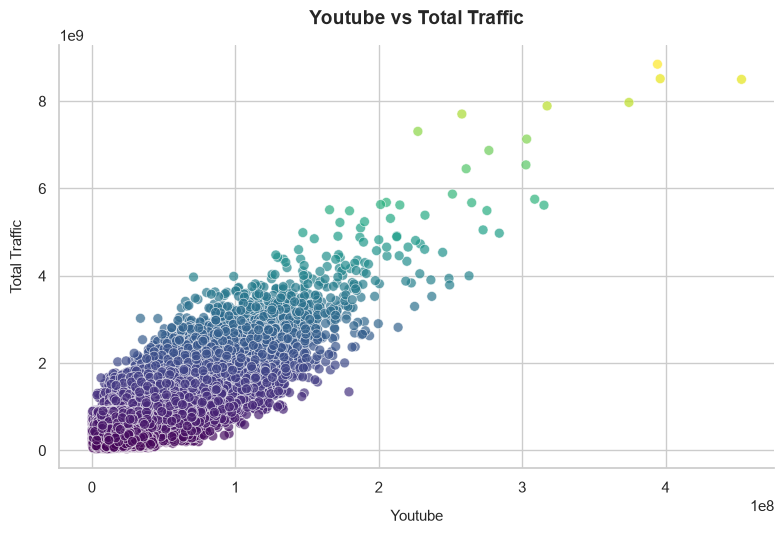

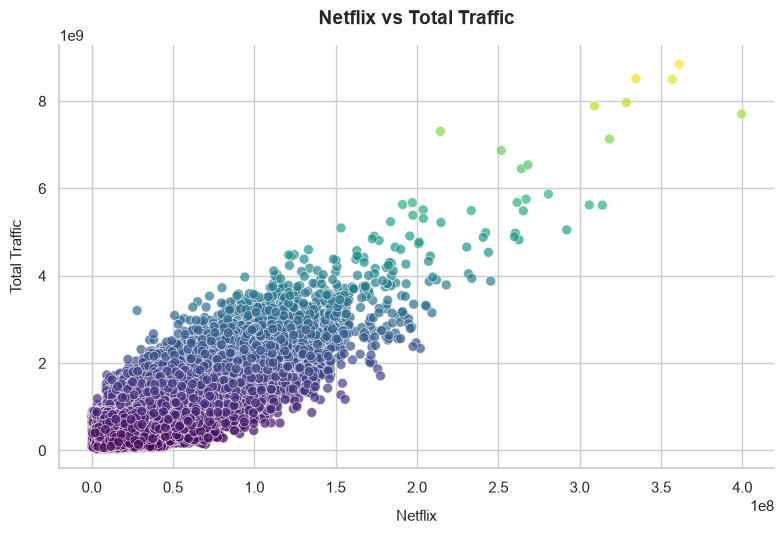

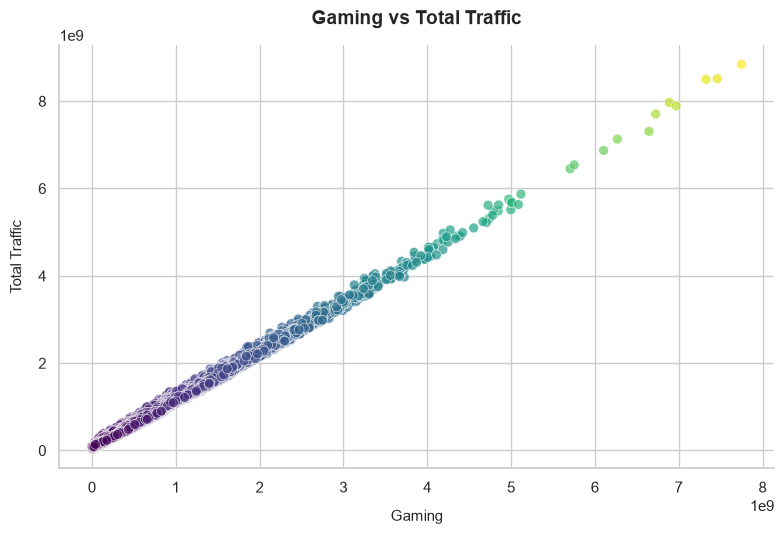

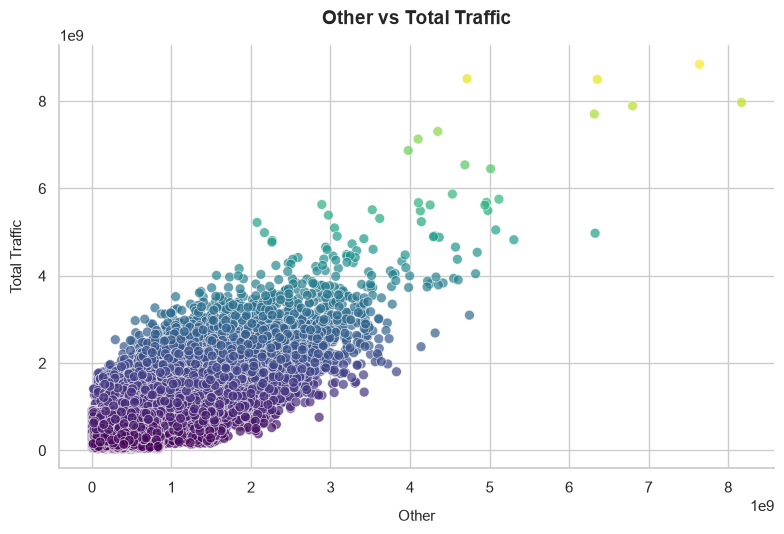

In [ ]:
for col in app_cols:
    plt.figure(figsize=(8, 5.5))  # Slightly larger for better breathing room

    # Create the scatter plot with a vibrant color gradient and edge highlights
    sns.scatterplot(
        data=df_overview,
        x=col,
        y="Total_Traffic",
        hue="Total_Traffic",     # Color gradient based on the traffic volume
        palette="viridis",       # Modern, high-contrast palette ('magma' or 'plasma' also look great)
        alpha=0.7,               # Slightly higher opacity for vividness
        edgecolor="w",           # White borders around points to make them pop
        linewidth=0.5,
        s=50                     # Optimal point size
    )

    # Clean up the labels and title while using original variables
    plt.title(f"{col.replace('_', ' ')} vs Total Traffic", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel(col.replace("_", " "), fontsize=11, labelpad=10)
    plt.ylabel("Total Traffic", fontsize=11, labelpad=10)

    # Remove the top and right spines for a minimalist, professional look
    sns.despine()
    
    # Optional: Removes the color legend if it feels too redundant on the side
    plt.legend([], frameon=False)

    plt.tight_layout()
    plt.show()

In [ ]:
# ### Observations

# - All application traffic variables show a positive relationship with Total Traffic.
# - Customers with higher usage of applications generally consume higher overall network traffic.
# - Gaming, YouTube, and Netflix exhibit the strongest positive relationship with Total Traffic because they are data-intensive applications.
# - Social Media and Email contribute comparatively less to the overall traffic volume.

In [ ]:
# - ### Variable Transformation (Decile Analysis)

# Users are segmented into five equal-sized 

In [ ]:
# duration group
df_overview["Duration_Decile"] = pd.qcut(
    df_overview["Total_Duration_ms"],
    q=5,
    labels=["D1", "D2", "D3", "D4", "D5"]
)

In [ ]:
# Aggregate Traffic
decile_analysis = (
    df_overview
    .groupby("Duration_Decile", observed=False)["Total_Traffic"]
    .agg(["count", "mean", "sum"])
    .reset_index()
)

decile_analysis

,Duration_Decile,count,mean,sum
0,D1,21372,5.403653e+08,1.154869e+13
1,D2,22826,5.507160e+08,1.257064e+13
2,D3,19916,5.809391e+08,1.156998e+13
3,D4,21372,6.538795e+08,1.397471e+13
4,D5,21370,1.130998e+09,2.416942e+13


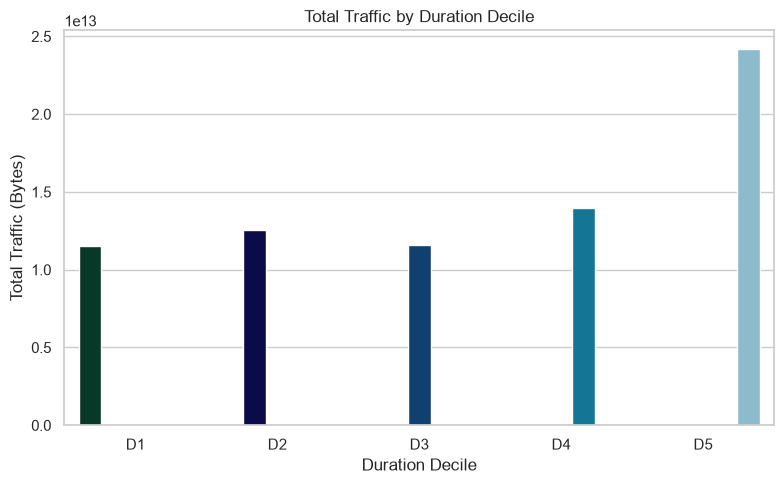

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=decile_analysis,
    x="Duration_Decile",
    y="sum",
    hue='Duration_Decile',
    palette='ocean'
)

plt.title("Total Traffic by Duration Decile")
plt.xlabel("Duration Decile")
plt.ylabel("Total Traffic (Bytes)")

plt.tight_layout()
plt.show()

In [ ]:
### Observations

- Users in the higher duration groups generate substantially more total traffic than users in the lower duration groups.
- This indicates a positive relationship between session duration and overall network usage.
- Long-duration users contribute a significant proportion of the network traffic and may represent high-value customers.

SyntaxError: invalid syntax (1949580887.py, line 3)

Correlation Analysis

In [ ]:
corr_cols = [
    "Social_Media",
    "Google",
    "Email",
    "Youtube",
    "Netflix",
    "Gaming",
    "Other"
]

corr_matrix = df_overview[corr_cols].corr()

corr_matrix

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Application Traffic")

plt.show()

In [ ]:
# ### Observations

# - Most application traffic variables exhibit weak to moderate positive correlations.
# - Gaming, YouTube, and Netflix tend to show relatively stronger relationships due to their high bandwidth requirements.
# - No extremely high correlations are observed, suggesting that each application contributes unique information to user behavior.
# - The correlation matrix indicates that customers distribute their network usage across multiple applications rather than relying on a single application.

In [ ]:
 ### Principal Component Analysis (PCA)

In [ ]:
features = df_overview[corr_cols]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
pca = PCA()

pca_result = pca.fit_transform(scaled_features)

In [ ]:
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": pca.explained_variance_ratio_.cumsum()
})

explained_variance

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=range(1, len(pca.explained_variance_ratio_) + 1),
    y=pca.explained_variance_ratio_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

plt.grid(True)

plt.show()

In [ ]:
# ### Interpretation

# - PCA successfully reduces the dimensionality of the application traffic variables.
# - The first few principal components explain the majority of the variance in user application usage.
# - Later principal components contribute relatively little additional information.
# - The reduced feature space can be used for efficient clustering and further analysis.

# Task2 USER ENGAGEMENT ANALYSIS

In [ ]:
#Insights -
# Here we aggregate user engagement metrics, normalize them, and apply k-means clustering to segment users.

# This helps identify high-engagement and low-engagement user groups.

In [ ]:
df_engagement = df_overview[
    [
        "MSISDN/Number",
        "Session_Frequency",
        "Total_Duration_ms",
        "Total_Traffic"
    ]
].copy()

df_engagement.head()

,MSISDN/Number,Session_Frequency,Total_Duration_ms,Total_Traffic
0,33601001722,1,116720.0,8.786906e+08
1,33601001754,1,181230.0,1.568596e+08
2,33601002511,1,134969.0,5.959665e+08
3,33601007832,1,49878.0,4.223207e+08
4,33601008617,2,37104.0,1.457411e+09


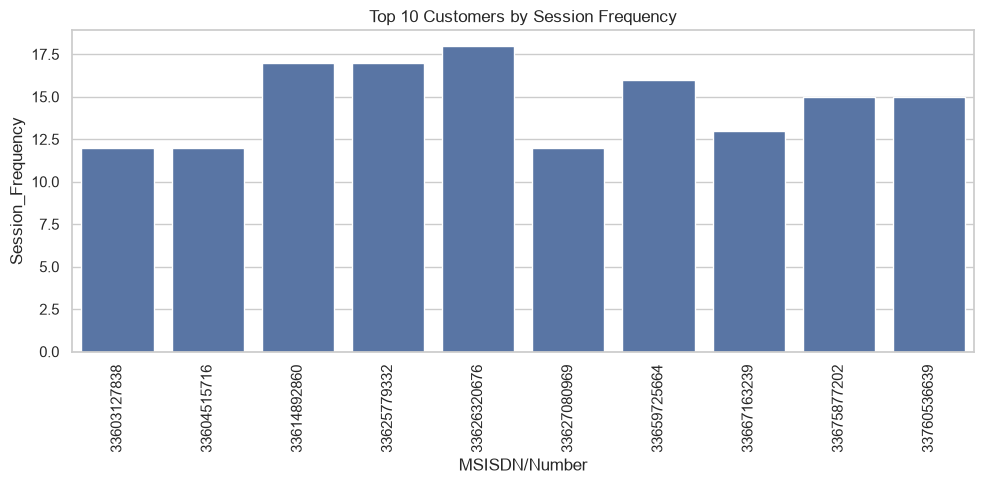

In [ ]:
plt.figure(figsize=(10,5))

top_sessions = df_engagement.nlargest(10, "Session_Frequency")

sns.barplot(
    data=top_sessions,
    x="MSISDN/Number",
    y="Session_Frequency"
)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by Session Frequency")

plt.tight_layout()

plt.show()

#Duration

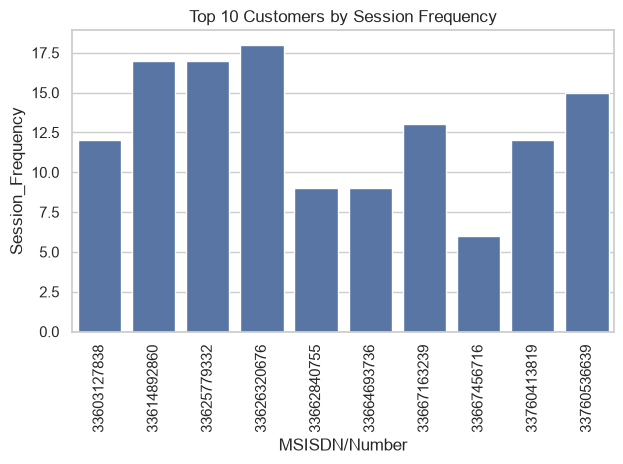

In [ ]:
total_duration = df_engagement.nlargest(10, "Total_Duration_ms")

sns.barplot(
    data=total_duration,
    x="MSISDN/Number",
    y="Session_Frequency"
)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by Session Frequency")

plt.tight_layout()

plt.show()

# Total Traffic

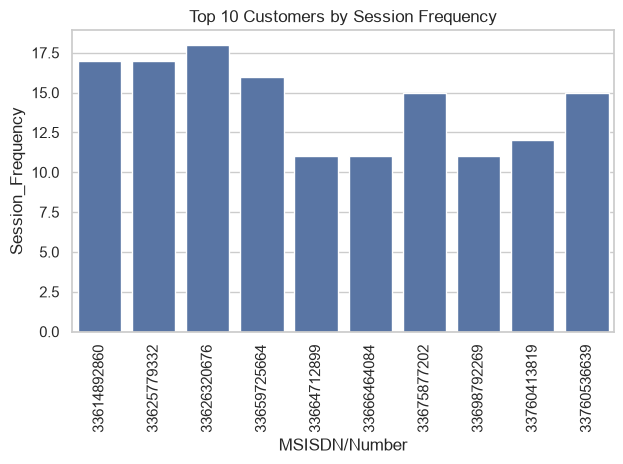

In [ ]:
total_traffic = df_engagement.nlargest(10, "Total_Traffic")

sns.barplot(
    data=total_traffic,
    x="MSISDN/Number",
    y="Session_Frequency"
)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by Session Frequency")

plt.tight_layout()

plt.show()

In [ ]:
# - ### Feature Normalization

# as we knew in EDA we found the extreme values in the distribution, by this we going to normalize them into a safe parameters

In [ ]:
engagement_features = df_engagement[
    [
        "Session_Frequency",
        "Total_Duration_ms",
        "Total_Traffic"
    ]
]

scaler = StandardScaler()

engagement_scaled = scaler.fit_transform(engagement_features)
engagement_scaled[:5]

array([[-0.4885642 , -0.15801408,  0.38229732],
       [-0.4885642 ,  0.18814798, -1.08766633],
       [-0.4885642 , -0.06008955, -0.19345265],
       [-0.4885642 , -0.51668971, -0.54707146],
       [ 0.75210255, -0.58523527,  1.56082524]])

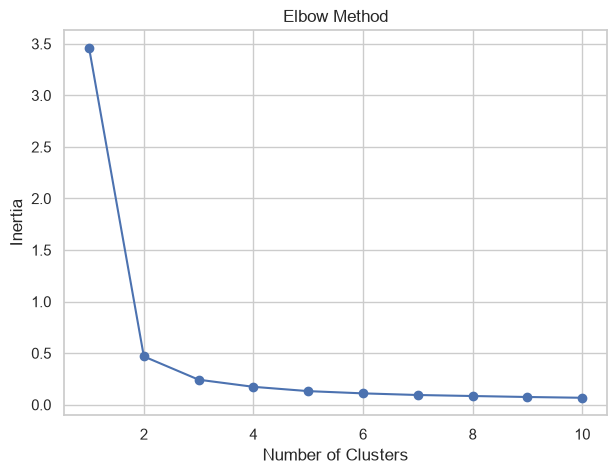

In [ ]:
#  Elbow Method

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(engagement_norm)

    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

#clustering

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_engagement["Engagement_Cluster"] = kmeans.fit_predict(
    engagement_scaled
)

df_engagement.head()

,MSISDN/Number,Session_Frequency,Total_Duration_ms,Total_Traffic,Engagement_Cluster
0,33601001722,1,116720.0,8.786906e+08,0
1,33601001754,1,181230.0,1.568596e+08,0
2,33601002511,1,134969.0,5.959665e+08,0
3,33601007832,1,49878.0,4.223207e+08,0
4,33601008617,2,37104.0,1.457411e+09,2


#Cluster stat

In [ ]:
cluster_summary = (
    df_engagement
    .groupby("Engagement_Cluster")
    .agg({
        "Session_Frequency": ["min", "max", "mean", "sum"],
        "Total_Duration_ms": ["min", "max", "mean", "sum"],
        "Total_Traffic": ["min", "max", "mean", "sum"]
    })
)

cluster_summary

Session_Frequency                      Total_Duration_ms  \
                                 min max      mean    sum               min   
Engagement_Cluster                                                            
0                                  1   2  1.028028  82088            7142.0   
1                                  1  18  4.409924  15642           66594.0   
2                                  1   4  2.182744  51205           18235.0   

                                                            Total_Traffic  \
                           max           mean           sum           min   
Engagement_Cluster                                                          
0                    1035261.0  103121.041127  8.234215e+09    33249009.0   
1                   18553754.0  658228.968424  2.334738e+09   370420998.0   
2                    1480875.0  215264.264078  5.049884e+09   177006936.0   

                                                              
                             max          mean           sum  
Engagement_Cluster                                            
0                   9.507607e+08  4.949519e+08  3.952191e+13  
1                   8.846226e+09  2.291641e+09  8.128452e+12  
2                   2.512802e+09  1.116121e+09  2.618309e+13

# Top 10 customers

In [ ]:
applications = [
    "Social_Media",
    "Google",
    "Email",
    "Youtube",
    "Netflix",
    "Gaming",
    "Other"
]

for app in applications:
    print(f"\nTop 10 Customers for {app}\n")

    display(
        df_overview.nlargest(10, app)[
            ["MSISDN/Number", app]
        ]
    )


Top 10 Customers for Social_Media



,MSISDN/Number,Social_Media
13526,33626320676,43374779.0
92923,33760536639,39783189.0
37052,33659725664,35412358.0
6437,33614892860,28294544.0
13180,33625779332,27135500.0
65118,33667163239,24247850.0
106137,33786323068,23974919.0
70960,33669068942,23800834.0
666,33603127838,23077825.0
31331,33658490784,23000066.0



Top 10 Customers for Google



,MSISDN/Number,Google
13526,33626320676,152191852.0
13180,33625779332,142307915.0
6437,33614892860,127973787.0
92923,33760536639,123223099.0
37052,33659725664,116516345.0
106137,33786323068,110254484.0
76363,33675877202,109860502.0
65118,33667163239,105032696.0
94654,33761268199,97089988.0
86313,33698756430,91935151.0



Top 10 Customers for Email



...

,MSISDN/Number,Netflix
37052,33659725664,399519079.0
6437,33614892860,361401046.0
13180,33625779332,356980607.0
92923,33760536639,334643269.0
13526,33626320676,328725740.0
92577,33760413819,318347546.0
65118,33667163239,313939488.0
76363,33675877202,309093159.0
106137,33786323068,305939790.0
94654,33761268199,292091341.0



Top 10 Customers for Gaming



,MSISDN/Number,Gaming
6437,33614892860,7.749432e+09
92923,33760536639,7.461045e+09
13180,33625779332,7.326673e+09
76363,33675877202,6.970568e+09
13526,33626320676,6.887572e+09
37052,33659725664,6.725559e+09
63028,33666464084,6.646303e+09
92577,33760413819,6.268620e+09
57241,33664712899,6.103856e+09
86455,33698792269,5.753743e+09



Top 10 Customers for Other



,MSISDN/Number,Other
13526,33626320676,8.167878e+09
6437,33614892860,7.639264e+09
76363,33675877202,6.798515e+09
13180,33625779332,6.354583e+09
666,33603127838,6.326671e+09
37052,33659725664,6.317415e+09
13936,33626948251,5.305448e+09
13994,33627080969,5.117791e+09
94654,33761268199,5.077779e+09
30715,33658361927,5.013651e+09


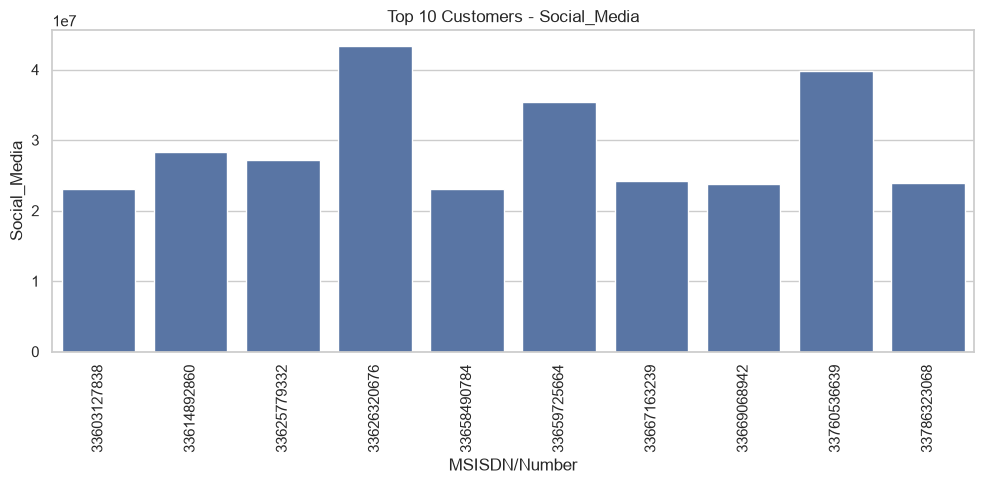

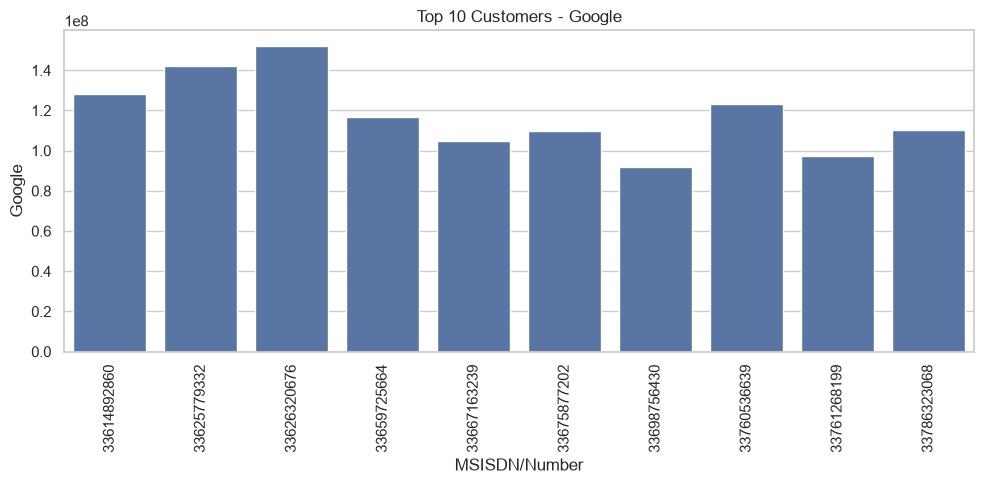

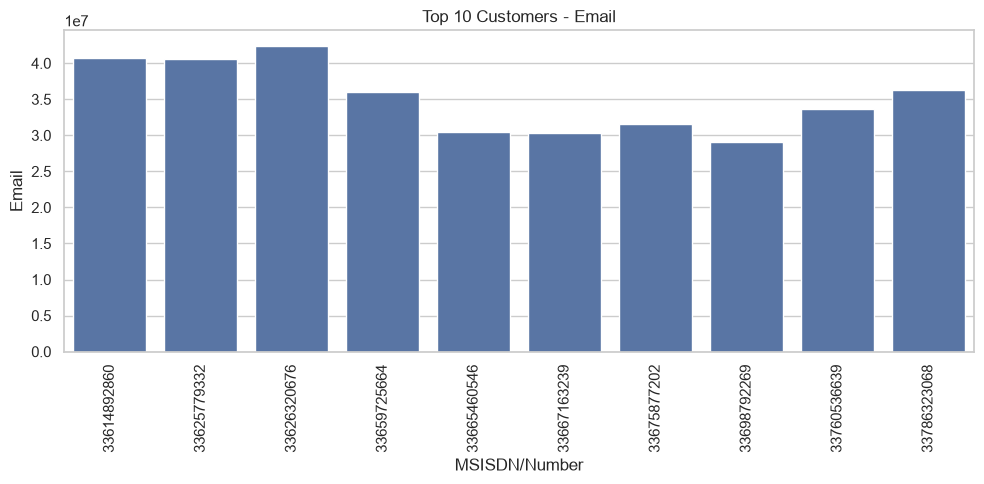

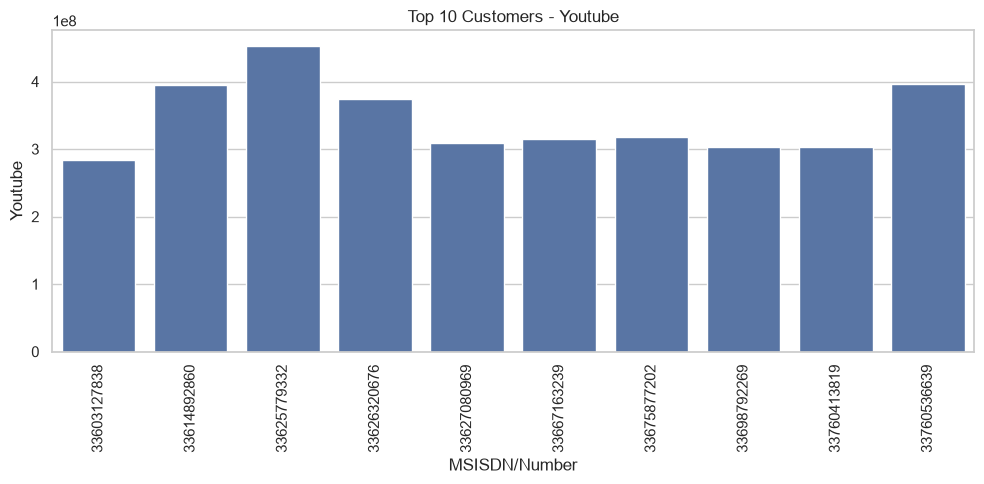

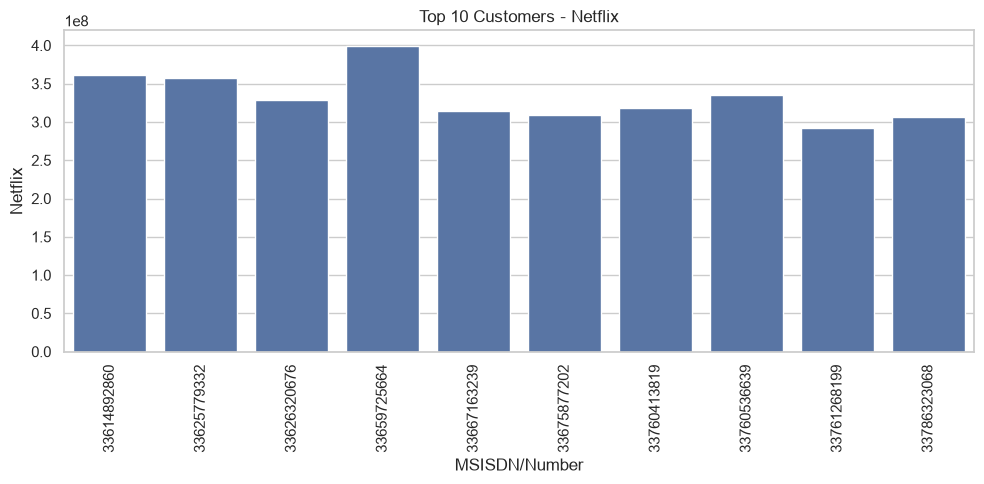

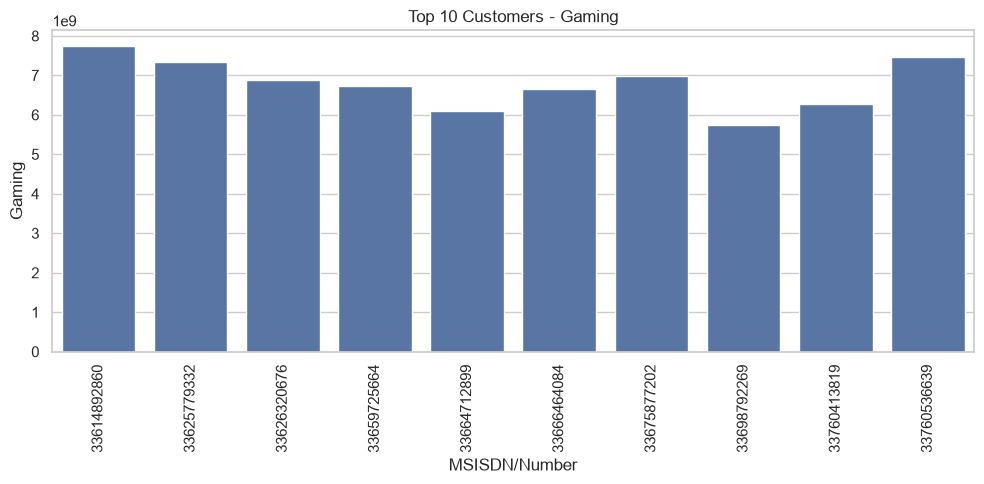

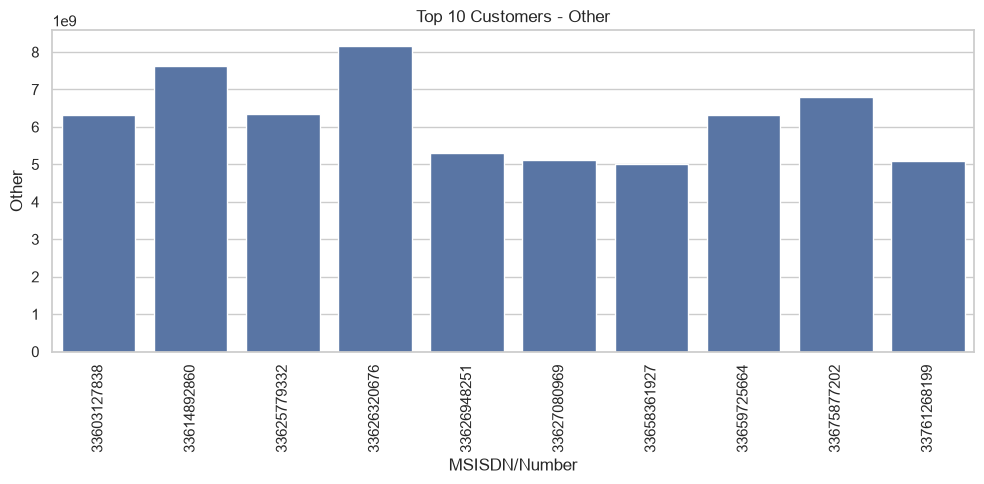

In [ ]:
for app in applications:

    top10 = df_overview.nlargest(10, app)

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=top10,
        x="MSISDN/Number",
        y=app
    )

    plt.xticks(rotation=90)

    plt.title(f"Top 10 Customers - {app}")

    plt.tight_layout()

    plt.show()

In [ ]:
application_usage = (
    df_overview[
        applications
    ]
    .sum()
    .sort_values(ascending=False)
)

application_usage

Gaming          6.408892e+13
Other           6.395425e+13
Youtube         3.372204e+12
Netflix         3.370060e+12
Google          1.162853e+12
Email           3.364677e+11
Social_Media    2.722655e+11
dtype: float64

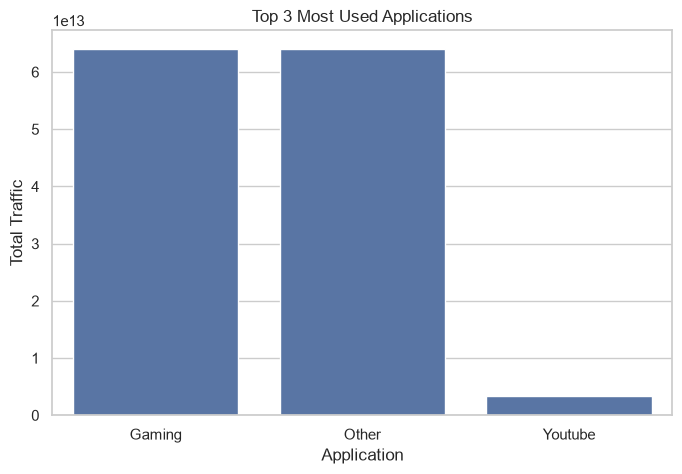

In [ ]:
top3_apps = application_usage.head(3)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top3_apps.index,
    y=top3_apps.values
)

plt.title("Top 3 Most Used Applications")

plt.xlabel("Application")

plt.ylabel("Total Traffic")

plt.show()

In [ ]:
# >Gaming and Other generated the highest traffic, followed by YouTube and Netflix. These applications dominate overall network usage due to multimedia streaming and interactive content.

In [ ]:
#  Silhouette Score


score = silhouette_score(
    engagement_norm,
    engagement_norm_df["engagement_cluster"]
)

print("\nSilhouette Score :", round(score,3))


Silhouette Score : 0.646


# Task 3 Experience Analytics

In [ ]:
# Insights -
# In this section, we aggregate network performance metrics like retransmission, RTT, and throughput on a per-user basis.

# Then we identify top and bottom users and use k-means clustering to create experience-based groups.

In [ ]:
df["Avg_TCP"] = (
    df["TCP DL Retrans. Vol (Bytes)"] +
    df["TCP UL Retrans. Vol (Bytes)"]
) / 2

df["Avg_RTT"] = (
    df["Avg RTT DL (ms)"] +
    df["Avg RTT UL (ms)"]
) / 2

df["Avg_Throughput"] = (
    df["Avg Bearer TP DL (kbps)"] +
    df["Avg Bearer TP UL (kbps)"]
) / 2

In [ ]:
df_experience = (
    df.groupby("MSISDN/Number")
      .agg(
          Avg_TCP=("Avg_TCP", "mean"),
          Avg_RTT=("Avg_RTT", "mean"),
          Avg_Throughput=("Avg_Throughput", "mean"),
          Handset_Type=("Handset Type", lambda x: x.mode().iloc[0])
      )
      .reset_index()
)

df_experience.head()

,MSISDN/Number,Avg_TCP,Avg_RTT,Avg_Throughput,Handset_Type
0,33601001722,0.0,23.00,38.0,Huawei P20 Lite Huawei Nova 3E
1,33601001754,0.0,15.50,49.5,Apple iPhone 7 (A1778)
2,33601002511,0.0,0.00,48.5,undefined
3,33601007832,533.0,42.00,124.0,Apple iPhone 5S (A1457)
4,33601008617,2342708.0,29.75,14211.0,Apple iPhone Se (A1723)


In [ ]:
def display_metric_statistics(df, column):
    print("=" * 80)
    print(f"{column}")
    print("=" * 80)

    print("\nTop 10 Values")
    display(df.nlargest(10, column)[["MSISDN/Number", column]])

    print("\nBottom 10 Values")
    display(df.nsmallest(10, column)[["MSISDN/Number", column]])

    print("\nMost Frequent Values")
    display(
        df[column]
        .value_counts()
        .head(10)
        .reset_index()
        .rename(columns={"index": column, column: "Frequency"})
    )

In [ ]:
display_metric_statistics(df_experience, "Avg_TCP")

display_metric_statistics(df_experience, "Avg_RTT")

display_metric_statistics(df_experience, "Avg_Throughput")

Avg_TCP

Top 10 Values


,MSISDN/Number,Avg_TCP
85785,33698575965,2.150739e+09
32273,33658706088,2.144060e+09
58026,33664907178,2.134324e+09
31942,33658633234,2.127330e+09
62049,33666125485,2.105629e+09
70079,33668768421,2.083297e+09
43629,33661305358,2.068969e+09
48341,33662396708,2.058902e+09
64113,33666824231,1.984060e+09
98211,33762643398,1.893435e+09



Bottom 10 Values


,MSISDN/Number,Avg_TCP
0,33601001722,0.0
1,33601001754,0.0
2,33601002511,0.0
8,33601014694,0.0
10,33601021045,0.0
12,33601022743,0.0
13,33601024291,0.0
14,33601025738,0.0
16,33601027208,0.0
18,33601032846,0.0



Most Frequent Values


...

,MSISDN/Number,Avg_Throughput
37838,33659907570,141965.50
49595,33662681056,132862.00
60763,33665658364,132588.25
52830,33663487108,127475.00
14564,33627953865,119491.00
10359,33621176428,117682.50
104697,33782399167,115491.00
27722,33651479599,114151.50
92374,33760327549,113667.00
98280,33762670789,113252.50



Bottom 10 Values


,MSISDN/Number,Avg_Throughput
857,33603452974,0.0
1204,33604131582,0.0
2473,33608514832,0.0
2605,33608752702,0.0
2671,33608892887,0.0
3238,33609847664,0.0
3738,33610640063,0.0
4276,33611523366,0.0
7196,33616110252,0.0
7518,33616605202,0.0



Most Frequent Values


,Frequency,count
0,7.5,2872
1,31.5,2138
2,48.5,1094
3,45.0,1062
4,49.0,1025
5,48.0,938
6,49.5,918
7,44.5,881
8,45.5,864
9,47.5,856


### Average TCP Retransmission
- The top 10 users experienced the highest TCP retransmission values, indicating relatively poor network reliability.
- The bottom 10 users had minimal retransmissions, suggesting stable network connections.
- The most frequent TCP retransmission values are concentrated around lower values, implying that most customers experience acceptable network performance.

### Average RTT
- The highest RTT values indicate users experiencing significant network latency.
- Most users have comparatively lower RTT values, reflecting satisfactory network responsiveness.
- The frequent RTT values suggest that low to moderate latency is common across the network.

### Average Throughput
- The top users achieved the highest throughput, indicating faster data transfer speeds.
- The bottom users experienced comparatively lower throughput, reflecting slower network performance.
- The most frequent throughput values are concentrated in the lower-to-middle range, indicating that the majority of customers receive moderate download and upload speeds.

- #### Distribution by Handset Type

In [ ]:
throughput_by_handset = (
    df_experience
    .groupby("Handset_Type")["Avg_Throughput"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=throughput_by_handset.index,
    y=throughput_by_handset.values
)

plt.xticks(rotation=90)
plt.title("Average Throughput by Handset Type")
plt.ylabel("Average Throughput")

plt.tight_layout()
plt.show()

- The average throughput varies across handset types, indicating that device capabilities may influence network performance.
- Certain handset models consistently achieve higher average throughput, suggesting better hardware or network compatibility.
- Handsets with lower throughput may be older devices or may not fully utilize the available network capacity.

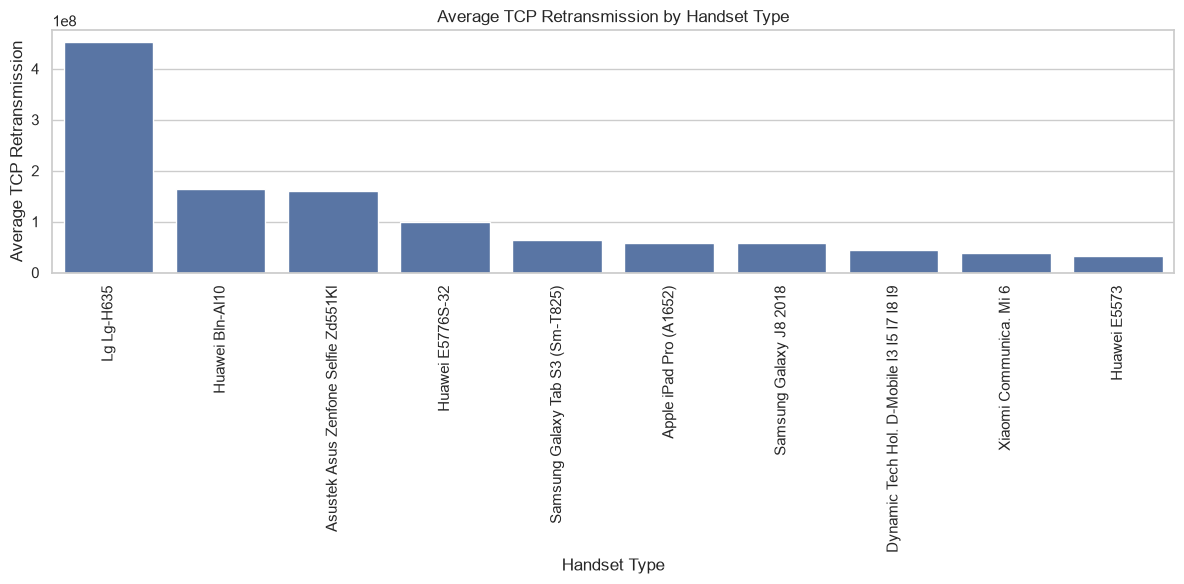

In [ ]:
tcp_by_handset = (
    df_experience
    .groupby("Handset_Type")["Avg_TCP"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=tcp_by_handset.index,
    y=tcp_by_handset.values
)

plt.xticks(rotation=90)

plt.title("Average TCP Retransmission by Handset Type")

plt.xlabel("Handset Type")

plt.ylabel("Average TCP Retransmission")

plt.tight_layout()

plt.show()

In [ ]:
# - TCP retransmission rates differ across handset types, indicating variations in connection reliability.
# - Handsets with higher retransmission values may experience less stable network performance, while lower values indicate more reliable communication.
# - These differences may arise from device hardware, software optimization, or network compatibility.

# K meanes clustering

In [ ]:
experience_features = df_experience[
    [
        "Avg_TCP",
        "Avg_RTT",
        "Avg_Throughput"
    ]
]

scaler = StandardScaler()

experience_scaled = scaler.fit_transform(
    experience_features
)

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_experience["Experience_Cluster"] = kmeans.fit_predict(
    experience_scaled
)

In [ ]:
experience_cluster_summary = (
    df_experience
    .groupby("Experience_Cluster")
    .agg({
        "Avg_TCP":["min","max","mean"],
        "Avg_RTT":["min","max","mean"],
        "Avg_Throughput":["min","max","mean"]
    })
)

experience_cluster_summary

Avg_TCP                             Avg_RTT            \
                            min           max          mean     min       max   
Experience_Cluster                                                              
0                           0.0  3.449378e+08  5.703807e+05     0.0  48462.00   
1                           0.0  5.551937e+08  9.329788e+06     0.0   4148.25   
2                   559336610.7  2.150739e+09  1.102623e+09    26.0    286.00   

                              Avg_Throughput                          
                         mean            min       max          mean  
Experience_Cluster                                                    
0                   55.584799            0.0   14916.5   2157.849044  
1                   50.637259         8241.0  141965.5  27516.441382  
2                   72.256869         7995.0   90919.5  35976.375909

In [ ]:
# - Users are grouped into three distinct experience clusters based on TCP retransmission, RTT, and throughput.
# - One cluster represents users with better network quality (low RTT, low TCP retransmission, high throughput), while another contains users experiencing comparatively poorer network performance.
# - These clusters can help identify customer groups requiring network optimization.

# 4. SATISFACTION ANALYSIS

In [ ]:
engagement_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_engagement["Engagement_Cluster"] = engagement_kmeans.fit_predict(
    engagement_scaled
)

experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_experience["Experience_Cluster"] = experience_kmeans.fit_predict(
    experience_scaled
)

In [ ]:
worst_experience_cluster = 2

experience_distance = cdist(
    experience_scaled,
    experience_kmeans.cluster_centers_
)

df_experience["Experience_Score"] = experience_distance[
    :,
    worst_experience_cluster
]

In [ ]:
satisfaction_df = df_engagement.merge(
    df_experience[
        [
            "MSISDN/Number",
            "Experience_Score"
        ]
    ],
    on="MSISDN/Number"
)

In [ ]:
print(satisfaction_df.columns.tolist())


['MSISDN/Number', 'Session_Frequency', 'Total_Duration_ms', 'Total_Traffic', 'Engagement_Cluster', 'Experience_Score', 'Engagement_Score', 'Satisfaction_Score']


In [ ]:
# Engagement Score बनाओ
satisfaction_df["Engagement_Score"] = (
    satisfaction_df["Session_Frequency"] +
    satisfaction_df["Total_Duration_ms"] +
    satisfaction_df["Total_Traffic"]
)

#  Experience Score (column 'Experience_Score')

#  Satisfaction Score ब(average of both)
satisfaction_df["Satisfaction_Score"] = (
    satisfaction_df["Engagement_Score"] +
    satisfaction_df["Experience_Score"]
) / 2

# Top 10 satisfied users
top10 = satisfaction_df.nlargest(10, "Satisfaction_Score")[[
    "MSISDN/Number", "Engagement_Score", "Experience_Score", "Satisfaction_Score"
]]

print("Top 10 satisfied users:")
print(top10.to_string(index=False))


Top 10 satisfied users:
 MSISDN/Number  Engagement_Score  Experience_Score  Satisfaction_Score
   33614892860      8856193409.0         22.314284        4.428097e+09
   33760536639      8524053412.0         22.350097        4.262027e+09
   33625779332      8518174493.0         22.373606        4.259087e+09
   33626320676      7979959206.0         22.402868        3.989980e+09
   33675877202      7895976570.0         22.341573        3.947988e+09
   33659725664      7709898227.0         22.346397        3.854949e+09
   33666464084      7313037706.0         22.297022        3.656519e+09
   33760413819      7137692193.0         22.335362        3.568846e+09
   33664712899      6874946004.0         22.301090        3.437473e+09
   33698792269      6546068265.0         22.370790        3.273034e+09


In [ ]:
top10_satisfied = satisfaction_df.nlargest(
    10,
    "Satisfaction_Score"
)

top10_satisfied

,MSISDN/Number,Session_Frequency,Total_Duration_ms,Total_Traffic,Engagement_Cluster,Experience_Score,Engagement_Score,Satisfaction_Score
6437,33614892860,17,9966898.0,8.846226e+09,1,22.314284,8.856193e+09,4.428097e+09
92923,33760536639,15,9279434.0,8.514774e+09,1,22.350097,8.524053e+09,4.262027e+09
13180,33625779332,17,18553754.0,8.499621e+09,1,22.373606,8.518174e+09,4.259087e+09
13526,33626320676,18,8791927.0,7.971167e+09,1,22.402868,7.979959e+09,3.989980e+09
76363,33675877202,15,4865947.0,7.891111e+09,1,22.341573,7.895977e+09,3.947988e+09
37052,33659725664,16,4035428.0,7.705863e+09,1,22.346397,7.709898e+09,3.854949e+09
63028,33666464084,11,4536757.0,7.308501e+09,1,22.297022,7.313038e+09,3.656519e+09
92577,33760413819,12,5321667.0,7.132371e+09,1,22.335362,7.137692e+09,3.568846e+09
57241,33664712899,11,2927785.0,6.872018e+09,1,22.301090,6.874946e+09,3.437473e+09
86455,33698792269,11,5169128.0,6.540899e+09,1,22.370790,6.546068e+09,3.273034e+09


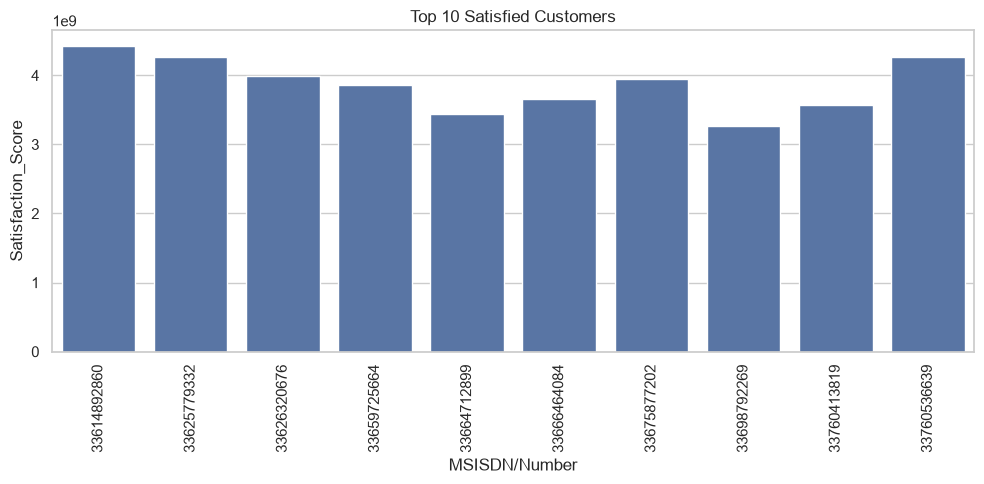

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_satisfied,
    x="MSISDN/Number",
    y="Satisfaction_Score"
)

plt.xticks(rotation=90)

plt.title("Top 10 Satisfied Customers")

plt.tight_layout()

plt.show()

In [ ]:
# > Customers with the highest satisfaction scores exhibit strong engagement and favorable network experience. These customers represent valuable users and may be prioritized for retention strategies and premium service offerings.

# Regression Model

In [ ]:
# Regression Model

X = satisfaction_df[["Engagement_Score", "Experience_Score"]]
y = satisfaction_df["Satisfaction_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

print("R² Score :", r2_score(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

# KMeans Clustering

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
satisfaction_df["Satisfaction_Cluster"] = kmeans.fit_predict(X)

cluster_result = (
    satisfaction_df.groupby("Satisfaction_Cluster")
    .agg(
        Average_Engagement=("Engagement_Score", "mean"),
        Average_Experience=("Experience_Score", "mean"),
        Average_Satisfaction=("Satisfaction_Score", "mean")
    )
)

print(cluster_result)


R² Score : 1.0
RMSE : 0.3423482778382464
                      Average_Engagement  Average_Experience  \
Satisfaction_Cluster                                           
0                           5.342232e+08           22.355307   
1                           1.582570e+09           22.259860   

                      Average_Satisfaction  
Satisfaction_Cluster                        
0                             2.671116e+08  
1                             7.912848e+08  


In [ ]:
import streamlit as st
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

st.subheader("Regression Model Performance")
st.write(f"R² Score: {r2_score(y_test, pred):.2f}")
st.write(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.4f}")

st.subheader("Satisfaction Clusters")
st.dataframe(cluster_result)

fig = px.scatter(
    satisfaction_df,
    x="Engagement_Score",
    y="Experience_Score",
    color="Satisfaction_Cluster",
    title="Satisfaction Clusters (Engagement vs Experience)",
    labels={"Engagement_Score":"Engagement Score","Experience_Score":"Experience Score"}
)
st.plotly_chart(fig, use_container_width=True)


2026-07-11 03:44:31.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-07-11 03:44:31.643 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.650 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.724 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.729 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-11 03:44:31.732 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

# MYSQL

In [ ]:

#  EXPORT DATA TO MYSQL
import mysql.connector
print("Connected")

Connected


In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Pathanaksa29@",
    database="telecom1_project"
)

print("✅ MySQL Connected Successfully")

✅ MySQL Connected Successfully


In [ ]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS user_satisfaction (

    MSISDN_Number VARCHAR(30),

    engagement_score DOUBLE,

    experience_score DOUBLE,

    satisfaction_score DOUBLE

)
""")

conn.commit()

print("✅ Table Created Successfully")

✅ Table Created Successfully


In [ ]:
cursor = conn.cursor()

sql = """
INSERT INTO user_satisfaction
(
    MSISDN_Number,
    engagement_score,
    experience_score,
    satisfaction_score
)
VALUES (%s, %s, %s, %s)
"""

for _, row in satisfaction_df.iterrows():
    cursor.execute(
        sql,
        (
            str(row["MSISDN/Number"]),      # सही नाम
            float(row["Engagement_Score"]), # तुम्हारे द्वारा बनाया गया
            float(row["Experience_Score"]), # पहले से मौजूद
            float(row["Satisfaction_Score"])# average वाला नया column
        )
    )

conn.commit()

print("✅ Data Inserted Successfully")


✅ Data Inserted Successfully


In [ ]:
import pandas as pd

df = pd.read_csv("final_user_satisfaction.csv")

df.to_sql(
    "user_satisfaction",
    engine,
    if_exists="replace",
    index=False
)

print("Data Uploaded Successfully")

Data Uploaded Successfully


In [ ]:
# Drop duplicate (_x) columns
dashboard_df = dashboard_df.drop(columns=[
    "youtube_usage_x",
    "netflix_usage_x",
    "google_usage_x",
    "gaming_usage_x",
    "email_usage_x",
    "social_media_usage_x",
    "handset_type_x"
])

# Rename (_y) columns
dashboard_df = dashboard_df.rename(columns={
    "youtube_usage_y": "youtube_usage",
    "netflix_usage_y": "netflix_usage",
    "google_usage_y": "google_usage",
    "gaming_usage_y": "gaming_usage",
    "email_usage_y": "email_usage",
    "social_media_usage_y": "social_media_usage",
    "handset_type_y": "handset_type"
})